# Multi-Asset DCA Portfolio Analysis

### Portfolio Performance, Risk, Benchmarks, and Dimensional Data Modeling

This project analyzes a normalized multi-asset investment period from May 2025 to May 2026. It combines a systematic traditional portfolio of ETFs, stocks, and gold with a simulated monthly DCA strategy for Bitcoin, Ethereum, and Solana.

The cryptocurrency component examines how a fixed recurring investment strategy would have performed if the same normalized monthly crypto investment had been invested systematically rather than through irregular purchases.

| Area | Scope |
|---|---|
| Traditional Portfolio | ETFs, stocks, and gold using a systematic monthly investment structure |
| Cryptocurrency Scenario | Simulated monthly DCA in Bitcoin, Ethereum, and Solana |
| Analysis | Performance, DCA returns, risk, drawdowns, diversification, correlations, asset contribution, benchmarks, and portfolio weights |
| Data Model | Validated dimension, bridge, and fact tables prepared for SQL and Power BI |

The traditional portfolio is also compared with iShares Core MSCI World, iShares Core DAX, iShares Core S&P 500, and iShares Physical Gold ETC.

All investment amounts are normalized to protect private financial information. Market data is sourced from Yahoo Finance in EUR. The cryptocurrency DCA and combined portfolio are hypothetical scenarios. Taxes and transaction costs are excluded.

## 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

## 2. Define Traditional Assets

In [2]:
# Define the traditional portfolio and corresponding Yahoo Finance tickers
tickers = {
    "Scalable_MSCI_AC_World_Xtrackers": "SCWX.DE",
    "VanEck_Defense_UCITS_ETF": "DFEN.DE",
    "Amundi_Nasdaq_100_Swap_EUR": "LYMS.DE",
    "LG_Artificial_Intelligence": "XMLD.DE",
    "ASML_Holding": "ASME.DE",
    "iShares_Physical_Gold_ETC": "PPFB.DE",
    "Rheinmetall": "RHM.DE"
}

## 3. Download Historical Traditional Asset Data

In [3]:
# Download daily historical prices from Yahoo Finance
data = yf.download(
    list(tickers.values()),
    start="2025-05-01",
    end="2026-06-01",
    auto_adjust=False,
    progress=False
)

# Preview the downloaded data
data.head()

Price        Adj Close                                                        \
Ticker         ASME.DE    DFEN.DE    LYMS.DE    PPFB.DE       RHM.DE SCWX.DE   
Date                                                                           
2025-05-02  603.544678  45.029999  71.680000  55.549999  1552.544922   8.862   
2025-05-05  601.067444  45.404999  71.510002  56.900002  1602.785889   8.886   
2025-05-06  596.311340  44.880001  70.900002  58.200001  1620.518066   8.839   
2025-05-07  598.887634  45.044998  70.419998  58.014999  1609.189087   8.791   
2025-05-08  624.353149  46.195000  72.320000  57.634998  1675.684570   8.929   

Price                       Close                        ...    Open          \
Ticker        XMLD.DE     ASME.DE    DFEN.DE    LYMS.DE  ...  RHM.DE SCWX.DE   
Date                                                     ...                   
2025-05-02  18.052000  609.099976  45.029999  71.680000  ...  1505.0   8.834   
2025-05-05  18.219999  606.599976  45.404999  71.510002  ...  1591.5   8.861   
2025-05-06  18.006001  601.799988  44.880001  70.900002  ...  1653.0   8.860   
2025-05-07  17.886000  604.400024  45.044998  70.419998  ...  1668.0   8.825   
2025-05-08  18.600000  630.099976  46.195000  72.320000  ...  1650.0   8.883   

Price                  Volume                                                 \
Ticker        XMLD.DE ASME.DE   DFEN.DE  LYMS.DE   PPFB.DE  RHM.DE   SCWX.DE   
Date                                                                           
2025-05-02  17.896000    8904  590048.0  50925.0   95333.0  383002   97534.0   
2025-05-05  18.000000    4380  419455.0  29996.0  100124.0  351409  156470.0   
2025-05-06  18.025999    2961  346481.0  36510.0  117350.0  473503   87419.0   
2025-05-07  17.986000    2332  319600.0  22642.0   91444.0  314284  118844.0   
2025-05-08  18.441999    3041  286557.0  37245.0   75776.0  344774  103492.0   

Price                
Ticker      XMLD.DE  
Date                 
2025-05-02  39532.0  
2025-05-05  31344.0  
2025-05-06  28084.0  
2025-05-07  32626.0  
2025-05-08  15808.0  

[5 rows x 42 columns]

In [4]:
# Check traditional asset data quality
traditional_close = data["Close"].copy()

print("Date range:", traditional_close.index.min(), "to", traditional_close.index.max())
print("Observations:", len(traditional_close))
print("Duplicate dates:", traditional_close.index.duplicated().sum())

print("\nMissing values:")
display(traditional_close.isna().sum())

print("\nBasic statistics:")
display(
    traditional_close.describe().T[
        ["count", "mean", "std", "min", "max"]
    ]
)

Date range: 2025-05-02 00:00:00 to 2026-05-29 00:00:00
Observations: 273
Duplicate dates: 0

Missing values:


Ticker
ASME.DE    0
DFEN.DE    2
LYMS.DE    2
PPFB.DE    2
RHM.DE     0
SCWX.DE    2
XMLD.DE    2
dtype: int64


Basic statistics:


,count,mean,std,min,max
Ticker,,,,,
ASME.DE,273.0,923.578387,247.323274,592.799988,1430.000000
DFEN.DE,271.0,53.403506,5.046104,44.880001,64.089996
LYMS.DE,271.0,85.421107,6.701397,70.419998,105.699997
PPFB.DE,271.0,68.167989,10.226672,54.270000,87.855003
RHM.DE,273.0,1663.974358,186.329428,1120.000000,1988.500000
SCWX.DE,271.0,10.131185,0.651371,8.791000,11.684000
XMLD.DE,271.0,23.528398,2.866095,17.886000,33.490002


## 4. Define Cryptocurrency Assets

In [5]:
# Define cryptocurrencies using Yahoo Finance EUR tickers
crypto_tickers = {
    "Bitcoin": "BTC-EUR",
    "Ethereum": "ETH-EUR",
    "Solana": "SOL-EUR"
}

## 5. Download Historical Cryptocurrency Data

In [6]:
# Download daily historical crypto prices in EUR
crypto_data = yf.download(
    list(crypto_tickers.values()),
    start="2025-05-01",
    end="2026-06-01",
    auto_adjust=False,
    progress=False
)

# Preview the downloaded data
crypto_data.head()

Price          Adj Close                                  Close               \
Ticker           BTC-EUR      ETH-EUR     SOL-EUR       BTC-EUR      ETH-EUR   
Date                                                                           
2025-05-01  85401.414062  1627.819580  133.508133  85401.414062  1627.819580   
2025-05-02  85741.179688  1630.335693  130.987259  85741.179688  1630.335693   
2025-05-03  84840.265625  1622.489624  129.877808  84840.265625  1622.489624   
2025-05-04  83307.414062  1597.495117  127.177353  83307.414062  1597.495117   
2025-05-05  83756.992188  1608.607178  129.679398  83756.992188  1608.607178   

Price                           High                                    Low  \
Ticker         SOL-EUR       BTC-EUR      ETH-EUR     SOL-EUR       BTC-EUR   
Date                                                                          
2025-05-01  133.508133  86330.234375  1659.428223  136.325500  83158.656250   
2025-05-02  130.987259  86137.414062  1651.228760  133.463974  85095.335938   
2025-05-03  129.877808  85771.101562  1635.236450  131.791885  84784.757812   
2025-05-04  127.177353  85218.164062  1636.786255  130.662094  83187.062500   
2025-05-05  129.679398  84141.640625  1619.356934  130.478897  82520.859375   

Price                                        Open                           \
Ticker          ETH-EUR     SOL-EUR       BTC-EUR      ETH-EUR     SOL-EUR   
Date                                                                         
2025-05-01  1583.244873  130.375183  83210.968750  1584.538330  130.403442   
2025-05-02  1602.319824  130.466385  85403.742188  1627.778198  133.505081   
2025-05-03  1603.888672  129.270370  85736.375000  1630.344849  130.987106   
2025-05-04  1595.281982  126.996925  84827.335938  1622.319336  129.877731   
2025-05-05  1572.796265  126.030701  83310.585938  1597.592896  127.179893   

Price            Volume                           
Ticker          BTC-EUR      ETH-EUR     SOL-EUR  
Date                                              
2025-05-01  29097101994  14038312634  2853909504  
2025-05-02  23376797858  12006209563  2498507835  
2025-05-03  13957068288   7382754456  1386770506  
2025-05-04  16074537504   7877956555  1445784166  
2025-05-05  22821496681  10068139288  1979252154

In [7]:
# Check cryptocurrency data quality
crypto_close = crypto_data["Close"].copy()

print("Date range:", crypto_close.index.min(), "to", crypto_close.index.max())
print("Observations:", len(crypto_close))
print("Duplicate dates:", crypto_close.index.duplicated().sum())

print("\nMissing values:")
display(crypto_close.isna().sum())

print("\nBasic statistics:")
display(
    crypto_close.describe().T[
        ["count", "mean", "std", "min", "max"]
    ]
)

Date range: 2025-05-01 00:00:00 to 2026-05-31 00:00:00
Observations: 396
Duplicate dates: 0

Missing values:


Ticker
BTC-EUR    0
ETH-EUR    0
SOL-EUR    0
dtype: int64


Basic statistics:


,count,mean,std,min,max
Ticker,,,,,
BTC-EUR,396.0,81671.101720,15315.194305,53242.796875,106538.164062
ETH-EUR,396.0,2560.150363,714.421605,1546.862183,4120.729980
SOL-EUR,396.0,122.433778,39.594152,65.932014,210.055481


## 6. Define Monthly DCA Purchase Dates

Investments are made on the 4th day of each month.

If the 4th falls on a weekend, the purchase is moved to the following Monday.
For traditional assets, if the resulting date is not a trading day, the next available trading day is used.

The same scheduled purchase dates are applied to the crypto portfolio for consistency.

In [8]:
# Create the 4th day of each month from May 2025 to May 2026
purchase_dates = pd.date_range(
    start="2025-05-01",
    end="2026-05-01",
    freq="MS"
) + pd.Timedelta(days=3)


# Move weekend dates to the following Monday
def adjust_weekend(date):
    if date.weekday() == 5:      # Saturday
        return date + pd.Timedelta(days=2)
    elif date.weekday() == 6:    # Sunday
        return date + pd.Timedelta(days=1)
    return date


adjusted_dates = [adjust_weekend(date) for date in purchase_dates]


# Create purchase schedule
purchase_schedule = pd.DataFrame({
    "Scheduled_Date": purchase_dates,
    "Purchase_Date": adjusted_dates
})

purchase_schedule

,Scheduled_Date,Purchase_Date
0,2025-05-04,2025-05-05
1,2025-06-04,2025-06-04
2,2025-07-04,2025-07-04
3,2025-08-04,2025-08-04
4,2025-09-04,2025-09-04
5,2025-10-04,2025-10-06
6,2025-11-04,2025-11-04
7,2025-12-04,2025-12-04
8,2026-01-04,2026-01-05
9,2026-02-04,2026-02-04


## 7. Match Purchase Dates with Trading Days

In [9]:
# Extract available trading dates from the Yahoo Finance dataset
trading_dates = data.index

# Find the next available trading day for each scheduled purchase date
def get_next_trading_day(date, available_dates):
    future_dates = available_dates[available_dates >= date]
    return future_dates[0] if len(future_dates) > 0 else pd.NaT

purchase_schedule["Trading_Date"] = purchase_schedule["Purchase_Date"].apply(
    lambda x: get_next_trading_day(x, trading_dates)
)

purchase_schedule

,Scheduled_Date,Purchase_Date,Trading_Date
0,2025-05-04,2025-05-05,2025-05-05
1,2025-06-04,2025-06-04,2025-06-04
2,2025-07-04,2025-07-04,2025-07-04
3,2025-08-04,2025-08-04,2025-08-04
4,2025-09-04,2025-09-04,2025-09-04
5,2025-10-04,2025-10-06,2025-10-06
6,2025-11-04,2025-11-04,2025-11-04
7,2025-12-04,2025-12-04,2025-12-04
8,2026-01-04,2026-01-05,2026-01-05
9,2026-02-04,2026-02-04,2026-02-04


## 8. Extract Monthly Traditional Asset Purchase Prices

In [10]:
# Extract closing prices for each monthly purchase date
close_prices = data["Close"].loc[purchase_schedule["Trading_Date"]].copy()

# Replace Yahoo Finance tickers with readable asset names
ticker_to_name = {ticker: name for name, ticker in tickers.items()}
close_prices = close_prices.rename(columns=ticker_to_name)

# Use the purchase date as index
close_prices.index = purchase_schedule["Trading_Date"].values
close_prices.index.name = "Purchase_Date"

close_prices

Ticker,ASML_Holding,VanEck_Defense_UCITS_ETF,Amundi_Nasdaq_100_Swap_EUR,iShares_Physical_Gold_ETC,Rheinmetall,Scalable_MSCI_AC_World_Xtrackers,LG_Artificial_Intelligence
Purchase_Date,,,,,,,
2025-05-05,606.599976,45.404999,71.510002,56.900002,1627.000000,8.886,18.219999
2025-06-04,654.799988,47.654999,77.059998,57.355000,1833.000000,9.240,19.879999
2025-07-04,659.500000,46.935001,78.239998,54.945000,1755.000000,9.323,20.490000
2025-08-04,602.500000,50.000000,80.959999,56.665001,1765.000000,9.534,21.100000
2025-09-04,647.099976,49.259998,81.820000,59.150002,1725.000000,9.743,22.145000
2025-10-06,897.099976,56.779999,86.529999,65.535004,1889.000000,10.154,25.504999
2025-11-04,917.900024,55.330002,90.540001,67.120003,1729.000000,10.386,25.655001
2025-12-04,957.400024,50.830002,89.010002,70.190002,1540.000000,10.338,24.665001
2026-01-05,1053.199951,55.779999,88.400002,73.629997,1752.000000,10.524,24.815001


## 9. Extract Monthly Cryptocurrency Purchase Prices

In [11]:
# Extract closing prices for each monthly crypto purchase date
crypto_close_prices = crypto_data["Close"].loc[
    purchase_schedule["Purchase_Date"]
].copy()

# Replace Yahoo Finance tickers with readable crypto names
crypto_ticker_to_name = {
    ticker: name for name, ticker in crypto_tickers.items()
}

crypto_close_prices = crypto_close_prices.rename(
    columns=crypto_ticker_to_name
)

# Use the purchase date as index
crypto_close_prices.index = purchase_schedule["Purchase_Date"].values
crypto_close_prices.index.name = "Purchase_Date"

crypto_close_prices

Ticker,Bitcoin,Ethereum,Solana
Purchase_Date,,,
2025-05-05,83756.992188,1608.607178,129.679398
2025-06-04,91701.437500,2284.080811,134.278961
2025-07-04,91720.289062,2129.711914,125.450150
2025-08-04,99324.070312,3210.035400,146.239441
2025-09-04,94986.453125,3687.763672,173.770309
2025-10-06,106538.164062,4003.338135,198.567764
2025-11-04,88446.335938,2866.568115,135.296494
2025-12-04,79136.664062,2691.935791,119.393883
2026-01-05,80141.148438,2753.927979,117.792664


## 10. Define Visualization Settings and Key Market Events

Consistent colors are assigned to each asset for all visualizations.
Selected market events are defined separately and used only as contextual markers in performance charts.

In [12]:
# Consistent colors for traditional assets
asset_colors = {
    "ASML_Holding": "#1F5AA6",
    "VanEck_Defense_UCITS_ETF": "#003B5C",
    "Amundi_Nasdaq_100_Swap_EUR": "#00A3E0",
    "iShares_Physical_Gold_ETC": "#D4A017",
    "Rheinmetall": "#65747F",
    "Scalable_MSCI_AC_World_Xtrackers": "#00A88F",
    "LG_Artificial_Intelligence": "#C23B8E"
}

# Consistent colors for cryptocurrencies
crypto_colors = {
    "Bitcoin": "#F7931A",
    "Ethereum": "#627EEA",
    "Solana": "#9945FF"
}

# Consistent colors for portfolio-level charts
portfolio_colors = {
    "Traditional": "#2E7D32",
    "Crypto": "#627EEA",
    "Combined": "#A64B5A"
}

benchmark_colors = {
    "Traditional Portfolio": portfolio_colors["Traditional"],
    "iShares Core MSCI World": "#4C78A8",
    "iShares Core DAX": "#F58518",
    "iShares Core S&P 500": "#7A5195",
    "iShares Physical Gold ETC": asset_colors["iShares_Physical_Gold_ETC"]
}

In [13]:
# Key events for traditional assets
traditional_events = [
    ("2025-05-12", "U.S.–China Tariff Truce"),
    ("2025-06-13", "Israel–Iran War Begins"),
    ("2025-06-24", "Israel–Iran Ceasefire"),
    ("2025-06-25", "NATO 5% Defense Spending Pledge"),
    ("2025-07-16", "ASML Warns on 2026 Growth"),
    ("2025-07-27", "U.S.–EU Tariff Deal"),
    ("2025-09-17", "Fed Rate Cut"),
    ("2025-10-10", "U.S.–China Tariff Escalation"),
    ("2026-01-28", "ASML AI Orders"),
    ("2026-02-28", "U.S.–Israeli Strikes on Iran")
]

# Key events for cryptocurrencies
crypto_events = [
    ("2025-05-07", "Ethereum Pectra"),
    ("2025-05-29", "SEC Staking Guidance"),
    ("2025-06-13", "Israel–Iran War Begins"),
    ("2025-06-24", "Israel–Iran Ceasefire"),
    ("2025-07-02", "First U.S. Solana Staking ETF"),
    ("2025-07-18", "GENIUS Act"),
    ("2025-07-29", "SEC Allows In-Kind Crypto ETPs"),
    ("2025-07-31", "SEC Project Crypto"),
    ("2025-09-17", "Fed Rate Cut"),
    ("2025-09-17", "SEC Crypto ETP Rules"),
    ("2025-10-10", "U.S.–China Tariff Escalation"),
    ("2026-02-28", "U.S.–Israeli Strikes on Iran"),
    ("2026-03-17", "SEC Crypto Securities Rules"),
    ("2026-05-14", "CLARITY Act Advances")
]

In [14]:
display_names = {
    "ASML_Holding": "ASML Holding",
    "LG_Artificial_Intelligence": "L&G Artificial Intelligence",
    "Amundi_Nasdaq_100_Swap_EUR": "Amundi Nasdaq 100",
    "Scalable_MSCI_AC_World_Xtrackers": "Scalable MSCI AC World",
    "iShares_Physical_Gold_ETC": "iShares Physical Gold ETC",
    "VanEck_Defense_UCITS_ETF": "VanEck Defense",
    "Rheinmetall": "Rheinmetall",
    "Bitcoin": "Bitcoin",
    "Ethereum": "Ethereum",
    "Solana": "Solana",
    "iShares Core MSCI World": "iShares Core MSCI World",
    "iShares Core DAX": "iShares Core DAX",
    "iShares Core S&P 500": "iShares Core S&P 500"
}

## 11. Normalize Traditional Asset Prices

Traditional asset prices are normalized to a starting value of 100 to compare their relative performance despite different price levels.

In [15]:
# Extract daily closing prices
traditional_daily = data["Close"].copy()

# Replace tickers with readable asset names
traditional_daily = traditional_daily.rename(columns=ticker_to_name)

# Normalize each asset to a starting value of 100
traditional_normalized = traditional_daily.apply(
    lambda x: x / x.dropna().iloc[0] * 100
)

traditional_normalized.head()

Ticker,ASML_Holding,VanEck_Defense_UCITS_ETF,Amundi_Nasdaq_100_Swap_EUR,iShares_Physical_Gold_ETC,Rheinmetall,Scalable_MSCI_AC_World_Xtrackers,LG_Artificial_Intelligence
Date,,,,,,,
2025-05-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2025-05-05,99.589558,100.832778,99.762837,102.430247,103.236041,100.270810,100.930641
2025-05-06,98.801512,99.666894,98.911832,104.770480,104.378173,99.740457,99.745183
2025-05-07,99.228378,100.033310,98.242185,104.437444,103.648477,99.198825,99.080432
2025-05-08,103.447710,102.587166,100.892856,103.753374,107.931472,100.756031,103.035677


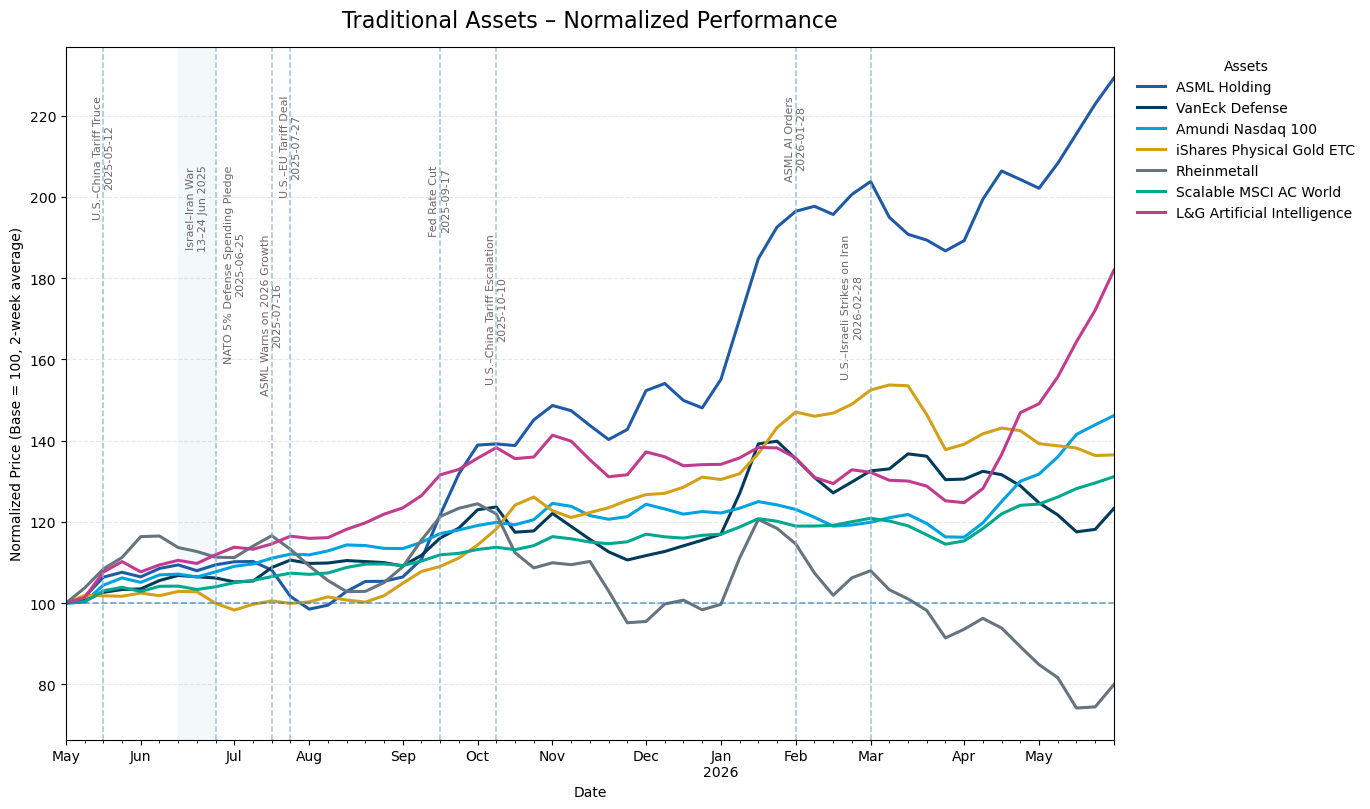

In [16]:
# Resample daily prices to weekly data
traditional_weekly = traditional_normalized.resample("W").last()

# Smooth short-term fluctuations
traditional_smooth = traditional_weekly.rolling(
    window=2,
    min_periods=1
).mean()

# Apply consistent asset colors
colors = [
    asset_colors[column]
    for column in traditional_smooth.columns
]

# Plot normalized performance
fig, ax = plt.subplots(figsize=(16, 9))

traditional_smooth.plot(
    ax=ax,
    linewidth=2.2,
    color=colors
)

# Set title and axis labels
ax.set_title(
    "Traditional Assets – Normalized Performance",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100, 2-week average)")

# Add horizontal reference lines
ax.yaxis.set_major_locator(MultipleLocator(20))

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

# Highlight the starting level
ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

# Highlight the Israel-Iran War period
war_start = pd.to_datetime("2025-06-13")
war_end = pd.to_datetime("2025-06-24")
war_middle = war_start + (war_end - war_start) / 2

ax.axvspan(
    war_start,
    war_end,
    alpha=0.05
)

# Show the war as one event label
ax.text(
    war_middle,
    0.83,
    "Israel–Iran War\n13–24 Jun 2025",
    transform=ax.get_xaxis_transform(),
    rotation=90,
    ha="center",
    va="top",
    fontsize=8,
    color="dimgray"
)

# Set alternating positions for the remaining events
label_positions = [0.93, 0.83, 0.73]

event_index = 0

# Add remaining event lines and labels
for date, label in traditional_events:

    # War start and ceasefire are already shown as one period
    if date in ["2025-06-13", "2025-06-24"]:
        continue

    event_date = pd.to_datetime(date)

    ax.axvline(
        x=event_date,
        linestyle="--",
        linewidth=1.1,
        color="#7fb3d5",
        alpha=0.8
    )

    label_date = event_date
    label_y = label_positions[event_index % len(label_positions)]

    # Move NATO text slightly right for clear space after the war label
    if date == "2025-06-25":
        label_date = event_date + pd.Timedelta(days=5)
        label_y = 0.83

    # Move only the text away from the ASML line
    elif date == "2026-02-28":
        label_date = event_date - pd.Timedelta(days=6)
        label_y = 0.73

    ax.text(
        label_date,
        label_y,
        f"{label}\n{date}",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="center",
        va="top",
        fontsize=8,
        color="dimgray"
    )

    event_index += 1

# Add asset legend with readable names
handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [
        display_names.get(column, column)
        for column in traditional_smooth.columns
    ],
    title="Assets",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

# Adjust spacing for legend
plt.subplots_adjust(right=0.78)

plt.show()

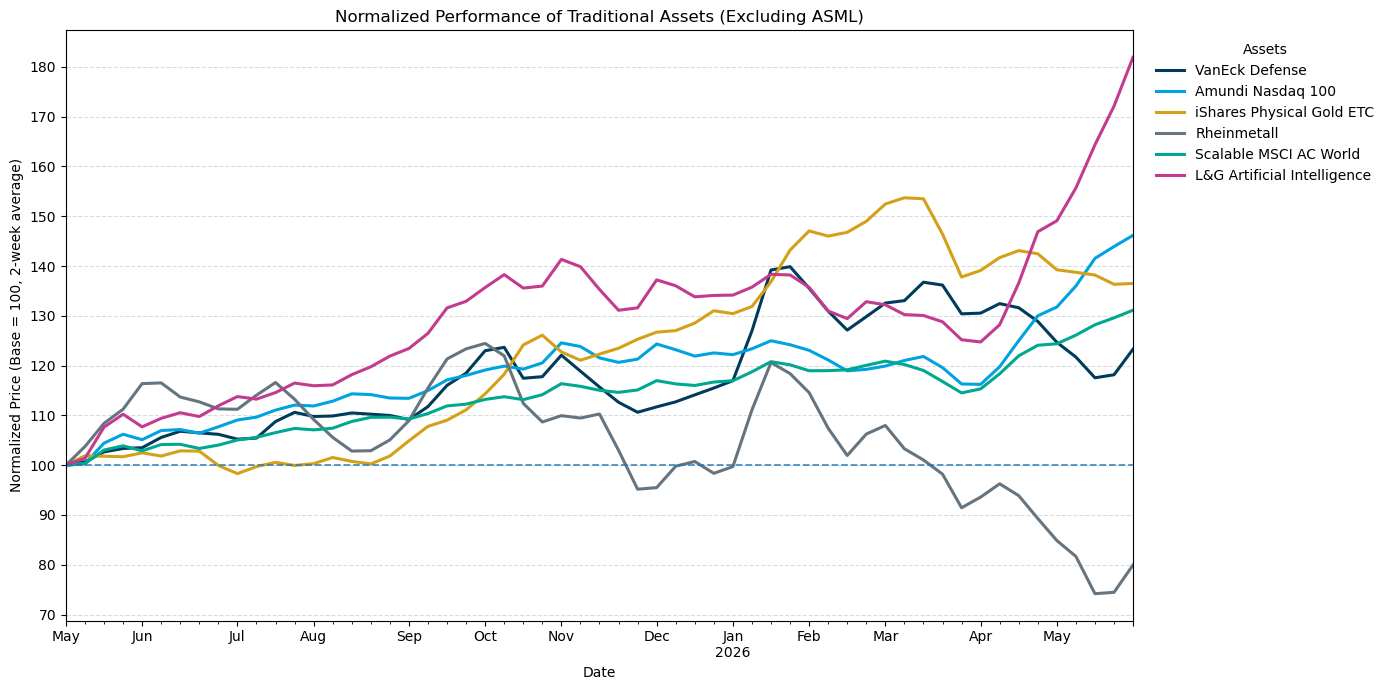

In [17]:
# Remove ASML for a clearer comparison
traditional_without_asml = traditional_smooth.drop(
    columns=["ASML_Holding"]
)

colors_without_asml = [
    asset_colors[column]
    for column in traditional_without_asml.columns
]

ax = traditional_without_asml.plot(
    figsize=(14, 7),
    linewidth=2.2,
    color=colors_without_asml
)

plt.title("Normalized Performance of Traditional Assets (Excluding ASML)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100, 2-week average)")

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45
)

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.3,
    alpha=0.8
)

# Add asset legend with readable names
handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [
        display_names.get(column, column)
        for column in traditional_without_asml.columns
    ],
    title="Assets",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

Prices are resampled weekly and smoothed with a two-week moving average to make the trend easier to read.

## 12. Normalize Cryptocurrency Prices

Cryptocurrency prices are normalized to a base value of 100 to compare the relative performance of Bitcoin, Ethereum, and Solana over the same investment period.

Key crypto, regulatory, macroeconomic, and geopolitical events are included to provide context for major market movements.

In [18]:
# Extract daily closing prices
crypto_daily = crypto_data["Close"].copy()

# Replace tickers with readable cryptocurrency names
crypto_daily = crypto_daily.rename(
    columns=crypto_ticker_to_name
)

# Normalize each cryptocurrency to a starting value of 100
crypto_normalized = crypto_daily.apply(
    lambda x: x / x.dropna().iloc[0] * 100
)

# Preview normalized data
crypto_normalized.head()

Ticker,Bitcoin,Ethereum,Solana
Date,,,
2025-05-01,100.000000,100.000000,100.000000
2025-05-02,100.397845,100.154570,98.111820
2025-05-03,99.342928,99.672571,97.280821
2025-05-04,97.548050,98.137112,95.258132
2025-05-05,98.074479,98.819746,97.132208


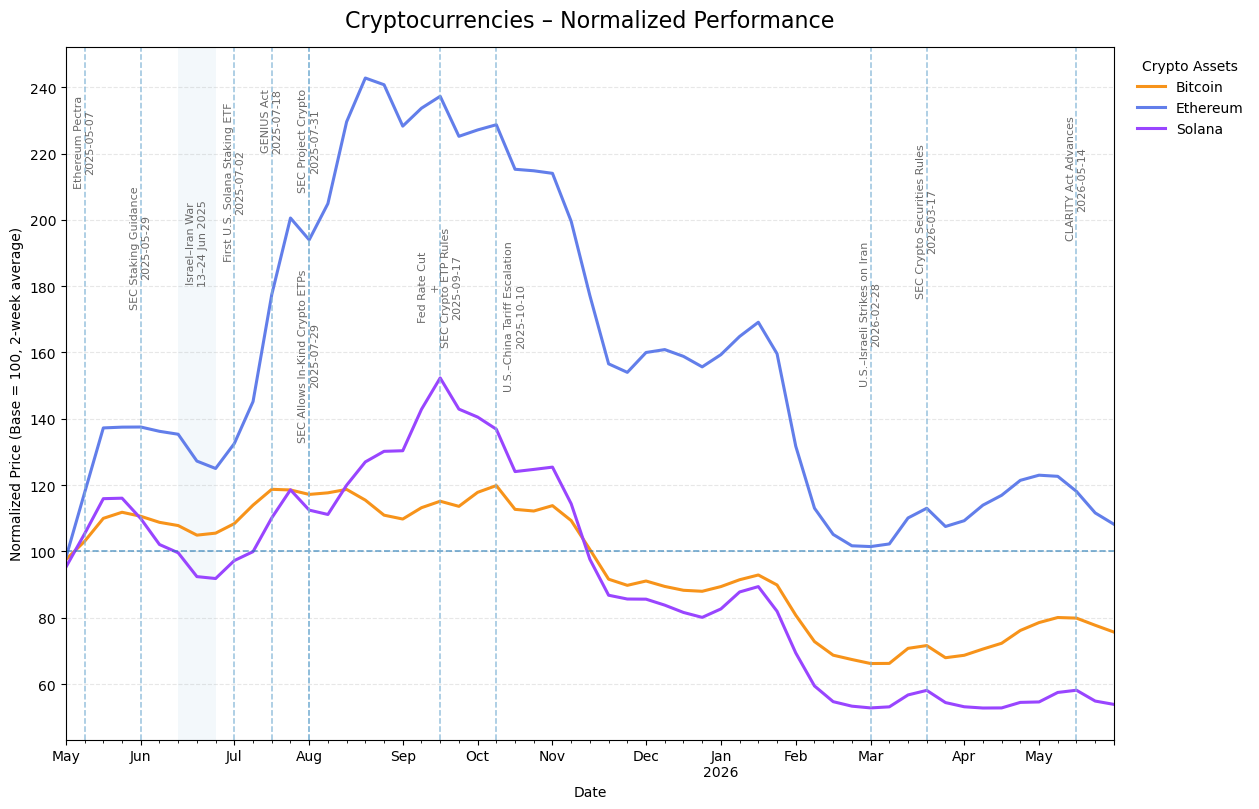

In [19]:
# Resample daily crypto prices to weekly data
crypto_weekly = crypto_normalized.resample("W").last()

# Smooth short-term fluctuations
crypto_smooth = crypto_weekly.rolling(
    window=2,
    min_periods=1
).mean()

# Apply consistent crypto colors
colors = [
    crypto_colors[column]
    for column in crypto_smooth.columns
]

# Plot normalized performance
fig, ax = plt.subplots(figsize=(16, 9))

crypto_smooth.plot(
    ax=ax,
    linewidth=2.2,
    color=colors
)

# Set title and axis labels
ax.set_title(
    "Cryptocurrencies – Normalized Performance",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100, 2-week average)")

# Add horizontal reference lines
ax.yaxis.set_major_locator(MultipleLocator(20))

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

# Highlight the starting level
ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

# Highlight the Israel-Iran War period
war_start = pd.to_datetime("2025-06-13")
war_end = pd.to_datetime("2025-06-24")
war_middle = war_start + (war_end - war_start) / 2

ax.axvspan(
    war_start,
    war_end,
    alpha=0.05
)

# Show the war as one period
ax.text(
    war_middle,
    0.78,
    "Israel–Iran War\n13–24 Jun 2025",
    transform=ax.get_xaxis_transform(),
    rotation=90,
    ha="center",
    va="top",
    fontsize=8,
    color="dimgray"
)

# Group events that occur on the same date
grouped_crypto_events = {}

for date, label in crypto_events:
    if date in ["2025-06-13", "2025-06-24"]:
        continue

    grouped_crypto_events.setdefault(date, []).append(label)

# Positions chosen to keep close events readable
event_positions = {
    "2025-05-07": 0.93,
    "2025-05-29": 0.80,
    "2025-07-02": 0.92,
    "2025-07-18": 0.94,
    "2025-07-29": 0.68,
    "2025-07-31": 0.94,
    "2025-09-17": 0.74,
    "2025-10-10": 0.94,
    "2026-02-28": 0.72,
    "2026-03-17": 0.86,
    "2026-05-14": 0.90
}

# Add event lines and labels
for date, labels in grouped_crypto_events.items():
    event_date = pd.to_datetime(date)

    ax.axvline(
        x=event_date,
        linestyle="--",
        linewidth=1.1,
        color="#7fb3d5",
        alpha=0.8
    )

    event_label = "\n+\n".join(labels)

    label_date = event_date
    label_y = event_positions.get(date, 0.85)

    # Move only the U.S.–China tariff label away from the Ethereum line
    if date == "2025-10-10":
        label_date = event_date + pd.Timedelta(days=7)
        label_y = 0.72

    ax.text(
        label_date,
        label_y,
        f"{event_label}\n{date}",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="center",
        va="top",
        fontsize=8,
        color="dimgray"
    )

# Add crypto legend
handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [
        display_names.get(column, column)
        for column in crypto_smooth.columns
    ],
    title="Crypto Assets",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

# Adjust spacing for legend
plt.subplots_adjust(right=0.78)

plt.show()

Prices are resampled weekly and smoothed with a two-week moving average to make the trend easier to read.

## 13. Define Portfolio Allocations

For the individual DCA simulations, the traditional and cryptocurrency portfolios are each modeled with a normalized monthly investment of 100 units. This allows their performance to be analyzed independently on a comparable basis.

The traditional portfolio consists of ETFs, stocks, and Gold, while the cryptocurrency portfolio consists of Bitcoin, Ethereum, and Solana.

In the later hypothetical combined portfolio analysis, these two strategies are rescaled while preserving their internal allocations. A total of 600 normalized units per month is compared as:

- 600 units in the traditional portfolio
- 500 units in the traditional portfolio + 100 units in the cryptocurrency portfolio

This corresponds to a hypothetical allocation of approximately 83.3% traditional assets and 16.7% cryptocurrencies.

In [20]:
# Traditional portfolio allocation
traditional_allocation = {
    "Scalable_MSCI_AC_World_Xtrackers": 30,
    "VanEck_Defense_UCITS_ETF": 25,
    "Amundi_Nasdaq_100_Swap_EUR": 15,
    "LG_Artificial_Intelligence": 10,
    "iShares_Physical_Gold_ETC": 10,
    "ASML_Holding": 5,
    "Rheinmetall": 5
}

# Cryptocurrency portfolio allocation
crypto_allocation = {
    "Bitcoin": 10,
    "Ethereum": 60,
    "Solana": 30
}

# Create allocation tables
traditional_allocation_df = pd.DataFrame(
    traditional_allocation.items(),
    columns=["Asset", "Allocation (%)"]
)

crypto_allocation_df = pd.DataFrame(
    crypto_allocation.items(),
    columns=["Asset", "Allocation (%)"]
)

display(traditional_allocation_df)
display(crypto_allocation_df)

,Asset,Allocation (%)
0,Scalable_MSCI_AC_World_Xtrackers,30
1,VanEck_Defense_UCITS_ETF,25
2,Amundi_Nasdaq_100_Swap_EUR,15
3,LG_Artificial_Intelligence,10
4,iShares_Physical_Gold_ETC,10
5,ASML_Holding,5
6,Rheinmetall,5


,Asset,Allocation (%)
0,Bitcoin,10
1,Ethereum,60
2,Solana,30


## 14. Traditional Portfolio DCA Simulation

The traditional portfolio is simulated using monthly investments of 100 normalized units based on the defined asset allocation and purchase dates.

In [21]:
# Calculate units purchased each month
traditional_units_purchased = close_prices.copy()

for asset, allocation in traditional_allocation.items():
    traditional_units_purchased[asset] = (
        allocation / close_prices[asset]
    )

# Calculate cumulative holdings
traditional_cumulative_units = traditional_units_purchased.cumsum()

traditional_units_purchased.head()

Ticker,ASML_Holding,VanEck_Defense_UCITS_ETF,Amundi_Nasdaq_100_Swap_EUR,iShares_Physical_Gold_ETC,Rheinmetall,Scalable_MSCI_AC_World_Xtrackers,LG_Artificial_Intelligence
Purchase_Date,,,,,,,
2025-05-05,0.008243,0.550600,0.209761,0.175747,0.003073,3.376097,0.548847
2025-06-04,0.007636,0.524604,0.194654,0.174353,0.002728,3.246753,0.503018
2025-07-04,0.007582,0.532652,0.191718,0.182000,0.002849,3.217848,0.488043
2025-08-04,0.008299,0.500000,0.185277,0.176476,0.002833,3.146633,0.473934
2025-09-04,0.007727,0.507511,0.183329,0.169062,0.002899,3.079134,0.451569


## 15. Calculate Traditional Portfolio Value

The cumulative portfolio value is calculated at each monthly purchase date and compared with the total amount invested.

In [22]:
# Calculate portfolio value at each purchase date
traditional_asset_values = (
    traditional_cumulative_units * close_prices
)

traditional_portfolio_value = traditional_asset_values.sum(axis=1)

# Calculate cumulative invested amount
traditional_invested = pd.Series(
    range(1, len(close_prices) + 1),
    index=close_prices.index
) * 100

# Combine results
traditional_dca = pd.DataFrame({
    "Invested": traditional_invested,
    "Portfolio_Value": traditional_portfolio_value
})

traditional_dca

,Invested,Portfolio_Value
Purchase_Date,,
2025-05-05,100,100.000000
2025-06-04,200,205.619576
2025-07-04,300,305.292396
2025-08-04,400,414.522175
2025-09-04,500,521.171126
2025-10-06,600,678.103361
2025-11-04,700,782.923502
2025-12-04,800,862.728861
2026-01-05,900,1001.587047


## 16. Calculate Traditional Portfolio Return

Profit or loss and portfolio return are calculated from the invested amount and current portfolio value at each purchase date.

In [23]:
# Calculate profit or loss
traditional_dca["Profit_Loss"] = (
    traditional_dca["Portfolio_Value"]
    - traditional_dca["Invested"]
)

# Calculate return in percent
traditional_dca["Return (%)"] = (
    traditional_dca["Profit_Loss"]
    / traditional_dca["Invested"]
) * 100

traditional_dca

,Invested,Portfolio_Value,Profit_Loss,Return (%)
Purchase_Date,,,,
2025-05-05,100,100.000000,0.000000,0.000000
2025-06-04,200,205.619576,5.619576,2.809788
2025-07-04,300,305.292396,5.292396,1.764132
2025-08-04,400,414.522175,14.522175,3.630544
2025-09-04,500,521.171126,21.171126,4.234225
2025-10-06,600,678.103361,78.103361,13.017227
2025-11-04,700,782.923502,82.923502,11.846215
2025-12-04,800,862.728861,62.728861,7.841108
2026-01-05,900,1001.587047,101.587047,11.287450


## 17. Visualize Traditional DCA Performance

The cumulative invested amount is compared with the portfolio value over the investment period.

The monthly purchase-date series is extended with the common final valuation date of 29 May 2026 without adding a new contribution.


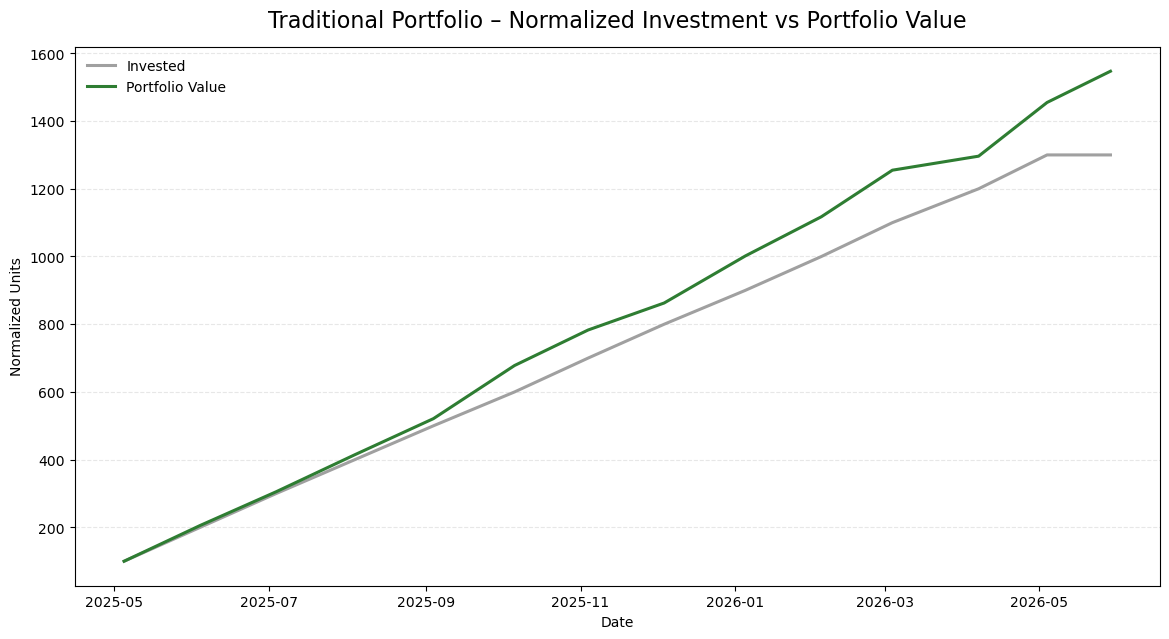

In [24]:
# Define the common final valuation date
final_valuation_date = (
    traditional_daily
    .loc["2026-05"]
    .dropna()
    .index[-1]
)

# Add the final valuation date to the display series only
traditional_final_value = (
    traditional_cumulative_units.iloc[-1]
    * traditional_daily.loc[
        final_valuation_date,
        traditional_cumulative_units.columns
    ]
).sum()

traditional_final_invested = traditional_invested.iloc[-1]

traditional_display_dca = traditional_dca.copy()
traditional_display_dca.loc[final_valuation_date] = {
    "Invested": traditional_final_invested,
    "Portfolio_Value": traditional_final_value,
    "Profit_Loss": traditional_final_value - traditional_final_invested,
    "Return (%)": (
        (traditional_final_value - traditional_final_invested)
        / traditional_final_invested
    ) * 100
}
traditional_display_dca = traditional_display_dca.sort_index()

# Plot invested amount and portfolio value
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    traditional_display_dca.index,
    traditional_display_dca["Invested"],
    linewidth=2.2,
    color="#A0A0A0",
    label="Invested"
)

ax.plot(
    traditional_display_dca.index,
    traditional_display_dca["Portfolio_Value"],
    linewidth=2.2,
    color=portfolio_colors["Traditional"],
    label="Portfolio Value"
)

ax.set_title(
    "Traditional Portfolio – Normalized Investment vs Portfolio Value",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Units")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

ax.legend(
    frameon=False
)

plt.show()


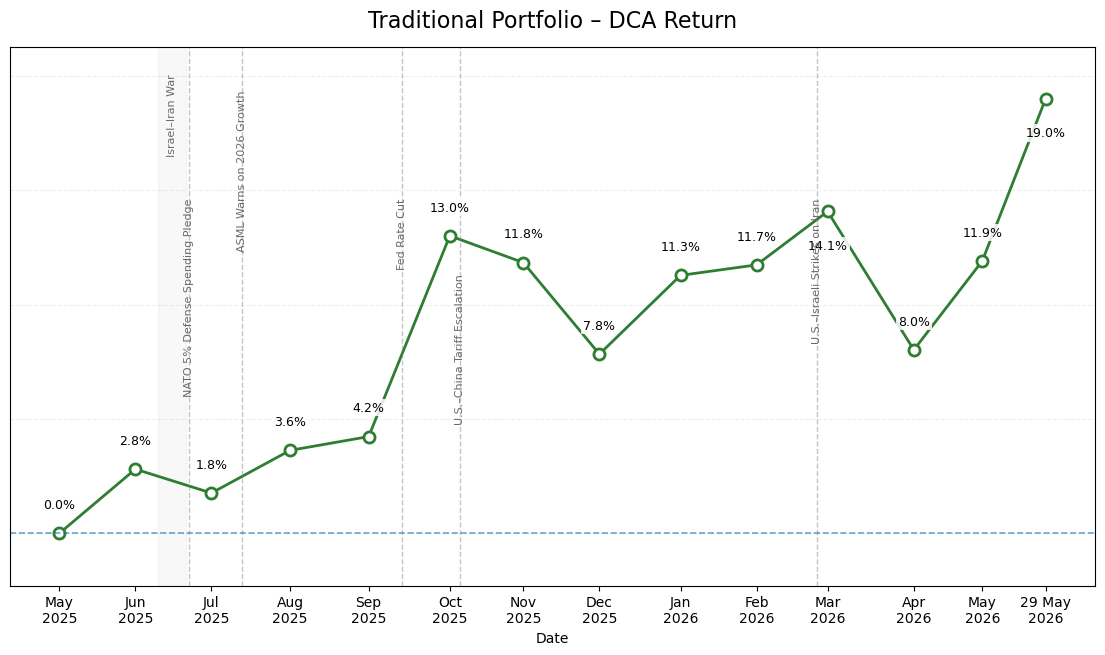

In [25]:
# Plot monthly traditional portfolio return plus final valuation
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    traditional_display_dca.index,
    traditional_display_dca["Return (%)"],
    linewidth=2.0,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    color=portfolio_colors["Traditional"]
)

# Add return values to each observation
for date, value in traditional_display_dca["Return (%)"].items():

    if value >= 13.5:
        offset = -20
        vertical_alignment = "top"
    else:
        offset = 16
        vertical_alignment = "bottom"

    ax.annotate(
        f"{value:.1f}%",
        (date, value),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.5
        )
    )

# Highlight the Israel-Iran War period
war_start = pd.to_datetime("2025-06-13")
war_end = pd.to_datetime("2025-06-24")
war_middle = war_start + (war_end - war_start) / 2

ax.axvspan(
    war_start,
    war_end,
    alpha=0.05,
    color="gray"
)

ax.text(
    war_middle,
    0.95,
    "Israel–Iran War",
    transform=ax.get_xaxis_transform(),
    rotation=90,
    ha="center",
    va="top",
    fontsize=8,
    color="dimgray"
)

# Selected traditional market events
selected_traditional_events = {
    "NATO 5% Defense Spending Pledge",
    "ASML Warns on 2026 Growth",
    "Fed Rate Cut",
    "U.S.–China Tariff Escalation",
    "U.S.–Israeli Strikes on Iran"
}

# Vertical positions for event labels
event_positions = {
    "2025-06-25": 0.72,
    "2025-07-16": 0.92,
    "2025-09-17": 0.72,
    "2025-10-10": 0.58,
    "2026-02-28": 0.72
}

# Add selected event lines and labels
for date, label in traditional_events:

    if label not in selected_traditional_events:
        continue

    event_date = pd.to_datetime(date)

    ax.axvline(
        x=event_date,
        linestyle="--",
        linewidth=1.0,
        color="gray",
        alpha=0.45
    )

    ax.text(
        event_date,
        event_positions.get(date, 0.85),
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="center",
        va="top",
        fontsize=8,
        color="dimgray"
    )

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional Portfolio – DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("")

# Show monthly observations plus the final valuation date
ax.set_xticks(traditional_display_dca.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in traditional_display_dca.index
    ]
)

# Hide y-axis numbers
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.margins(y=0.12)

plt.show()


## 18. Simulated Cryptocurrency DCA Strategy

This section tests a hypothetical monthly DCA strategy using Bitcoin, Ethereum, and Solana.

The simulation follows the same monthly purchase schedule as the traditional portfolio. It does not represent the actual cryptocurrency transactions, which were made irregularly.

Transaction fees, taxes, and trading costs are excluded.

In [26]:
# Calculate crypto units purchased each month
crypto_units_purchased = crypto_close_prices.copy()

for asset, allocation in crypto_allocation.items():
    crypto_units_purchased[asset] = (
        allocation / crypto_close_prices[asset]
    )

# Calculate cumulative holdings
crypto_cumulative_units = crypto_units_purchased.cumsum()

crypto_units_purchased.head()

Ticker,Bitcoin,Ethereum,Solana
Purchase_Date,,,
2025-05-05,0.000119,0.037299,0.231340
2025-06-04,0.000109,0.026269,0.223415
2025-07-04,0.000109,0.028173,0.239139
2025-08-04,0.000101,0.018691,0.205143
2025-09-04,0.000105,0.016270,0.172642


## 19. Calculate Simulated Cryptocurrency Portfolio Value

The cumulative cryptocurrency portfolio value is calculated at each monthly purchase date and compared with the total amount invested.

In [27]:
# Calculate crypto portfolio value at each purchase date
crypto_asset_values = (
    crypto_cumulative_units * crypto_close_prices
)

crypto_portfolio_value = crypto_asset_values.sum(axis=1)

# Calculate cumulative invested amount
crypto_invested = pd.Series(
    range(1, len(crypto_close_prices) + 1),
    index=crypto_close_prices.index
) * 100

# Combine results
crypto_dca = pd.DataFrame({
    "Invested": crypto_invested,
    "Portfolio_Value": crypto_portfolio_value
})

crypto_dca

,Invested,Portfolio_Value
Purchase_Date,,
2025-05-05,100,100.000000
2025-06-04,200,227.207300
2025-07-04,300,313.383717
2025-08-04,400,529.485227
2025-09-04,500,705.092616
2025-10-06,600,877.929076
2025-11-04,700,727.964919
2025-12-04,800,769.609262
2026-01-05,900,879.237570


## 20. Calculate Simulated Cryptocurrency Portfolio Return

Profit or loss and portfolio return are calculated from the invested amount and cryptocurrency portfolio value at each purchase date.

In [28]:
# Calculate profit or loss
crypto_dca["Profit_Loss"] = (
    crypto_dca["Portfolio_Value"]
    - crypto_dca["Invested"]
)

# Calculate return in percent
crypto_dca["Return (%)"] = (
    crypto_dca["Profit_Loss"]
    / crypto_dca["Invested"]
) * 100

crypto_dca

,Invested,Portfolio_Value,Profit_Loss,Return (%)
Purchase_Date,,,,
2025-05-05,100,100.000000,0.000000,0.000000
2025-06-04,200,227.207300,27.207300,13.603650
2025-07-04,300,313.383717,13.383717,4.461239
2025-08-04,400,529.485227,129.485227,32.371307
2025-09-04,500,705.092616,205.092616,41.018523
2025-10-06,600,877.929076,277.929076,46.321513
2025-11-04,700,727.964919,27.964919,3.994988
2025-12-04,800,769.609262,-30.390738,-3.798842
2026-01-05,900,879.237570,-20.762430,-2.306937


## 21. Visualize Simulated Cryptocurrency DCA Return

The chart shows the hypothetical return of a systematic monthly cryptocurrency DCA strategy over the investment period.

This chart uses the cryptocurrency purchase dates and adds the common final valuation date of 29 May 2026 without a new contribution; Section 22 values the same strategy on common observation dates for direct comparison with the traditional portfolio.


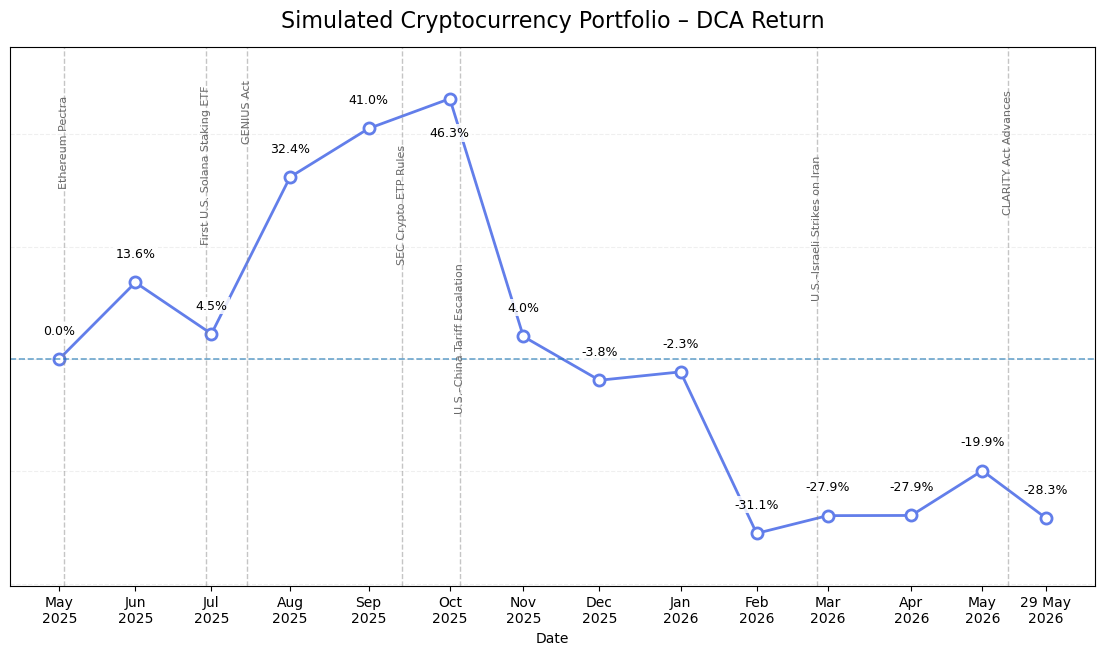

In [29]:
# Add the final valuation date to the crypto display series only
crypto_final_value = (
    crypto_cumulative_units.iloc[-1]
    * crypto_daily.loc[
        final_valuation_date,
        crypto_cumulative_units.columns
    ]
).sum()

crypto_final_invested = crypto_invested.iloc[-1]

crypto_display_dca = crypto_dca.copy()
crypto_display_dca.loc[final_valuation_date] = {
    "Invested": crypto_final_invested,
    "Portfolio_Value": crypto_final_value,
    "Profit_Loss": crypto_final_value - crypto_final_invested,
    "Return (%)": (
        (crypto_final_value - crypto_final_invested)
        / crypto_final_invested
    ) * 100
}
crypto_display_dca = crypto_display_dca.sort_index()

# Plot monthly crypto portfolio return plus final valuation
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    crypto_display_dca.index,
    crypto_display_dca["Return (%)"],
    linewidth=2.0,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    color=portfolio_colors["Crypto"]
)

# Add return values to each observation
highest_value = crypto_display_dca["Return (%)"].max()

for date, value in crypto_display_dca["Return (%)"].items():

    if value == highest_value:
        offset = -20
        vertical_alignment = "top"
    else:
        offset = 16
        vertical_alignment = "bottom"

    ax.annotate(
        f"{value:.1f}%",
        (date, value),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.5
        )
    )

# Selected market events
selected_crypto_events = {
    "Ethereum Pectra",
    "First U.S. Solana Staking ETF",
    "GENIUS Act",
    "SEC Crypto ETP Rules",
    "U.S.–China Tariff Escalation",
    "U.S.–Israeli Strikes on Iran",
    "CLARITY Act Advances"
}

# Vertical positions for event labels
event_positions = {
    "2025-05-07": 0.91,
    "2025-07-02": 0.93,
    "2025-07-18": 0.94,
    "2025-09-17": 0.82,
    "2025-10-10": 0.60,
    "2026-02-28": 0.80,
    "2026-05-14": 0.92
}

# Add event lines and labels
for date, label in crypto_events:

    if label not in selected_crypto_events:
        continue

    event_date = pd.to_datetime(date)

    if event_date > crypto_display_dca.index.max():
        continue

    ax.axvline(
        x=event_date,
        linestyle="--",
        linewidth=1.0,
        color="gray",
        alpha=0.45
    )

    ax.text(
        event_date,
        event_positions.get(date, 0.88),
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="center",
        va="top",
        fontsize=8,
        color="dimgray"
    )

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Simulated Cryptocurrency Portfolio – DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("")

# Show monthly observations plus the final valuation date
ax.set_xticks(crypto_display_dca.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in crypto_display_dca.index
    ]
)

# Hide y-axis numbers
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.margins(y=0.12)

plt.show()


## 22. Compare Traditional and Simulated Cryptocurrency DCA Returns

The traditional portfolio is compared with the hypothetical cryptocurrency DCA strategy using the same normalized monthly investment amount.

For a fair comparison, both portfolios are valued on the same monthly observation date after both scheduled purchases are available. This avoids comparing portfolio values from different calendar days when a market holiday shifts the traditional trading date.

The common final valuation date of 29 May 2026 is added as an additional end-of-period observation without an additional contribution.


,Traditional,Crypto
Observation_Date,,
2025-05-05,0.00,0.00
2025-06-04,2.81,13.60
2025-07-04,1.76,4.46
2025-08-04,3.63,32.37
2025-09-04,4.23,41.02
2025-10-06,13.02,46.32
2025-11-04,11.85,3.99
2025-12-04,7.84,-3.80
2026-01-05,11.29,-2.31


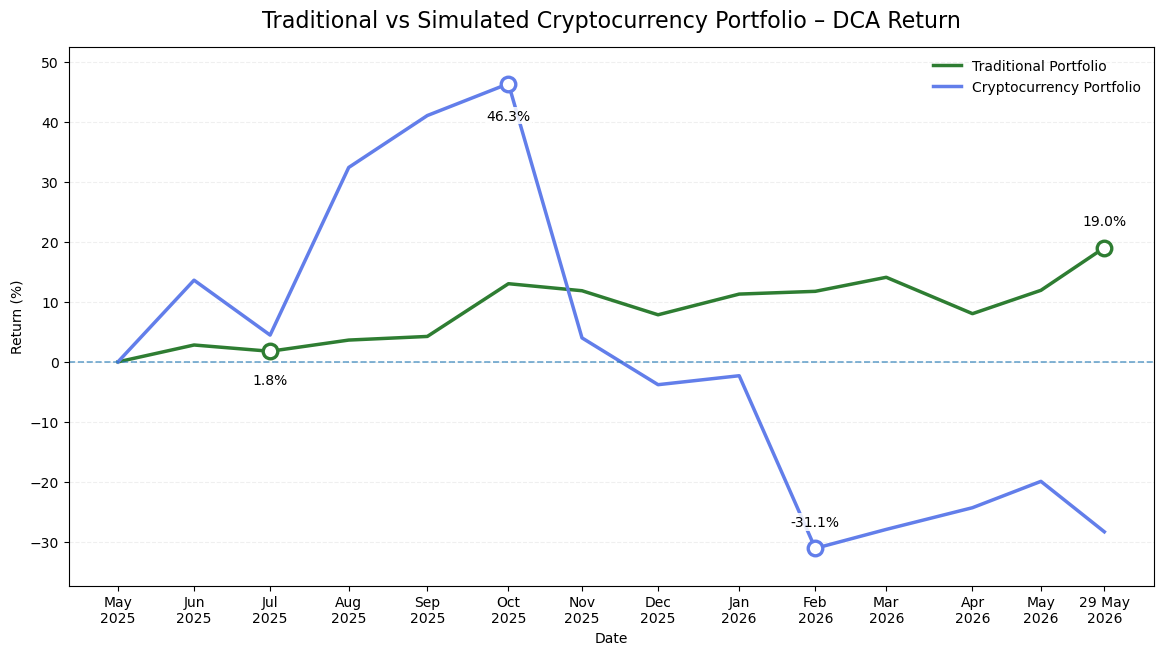

In [30]:
# Define a common final valuation date for end-of-period comparisons
final_valuation_date = (
    traditional_daily
    .loc["2026-05"]
    .dropna()
    .index[-1]
)

# Use the later monthly purchase date so both portfolios are valued
# on the same observation date after both purchases are available
common_observation_dates = pd.DatetimeIndex(
    [
        max(traditional_date, crypto_date)
        for traditional_date, crypto_date in zip(
            traditional_dca.index,
            crypto_dca.index
        )
    ],
    name="Observation_Date"
)

traditional_common_values = []
crypto_common_values = []

for i, observation_date in enumerate(common_observation_dates):

    traditional_value = (
        traditional_cumulative_units.iloc[i]
        * traditional_daily.loc[
            observation_date,
            traditional_cumulative_units.columns
        ]
    ).sum()

    crypto_value = (
        crypto_cumulative_units.iloc[i]
        * crypto_daily.loc[
            observation_date,
            crypto_cumulative_units.columns
        ]
    ).sum()

    traditional_common_values.append(traditional_value)
    crypto_common_values.append(crypto_value)

# Build aligned 100-unit DCA series
common_invested = pd.Series(
    range(1, len(common_observation_dates) + 1),
    index=common_observation_dates,
    dtype=float
) * 100

traditional_common_dca = pd.DataFrame({
    "Invested": common_invested,
    "Portfolio_Value": traditional_common_values
}, index=common_observation_dates)

crypto_common_dca = pd.DataFrame({
    "Invested": common_invested,
    "Portfolio_Value": crypto_common_values
}, index=common_observation_dates)

for portfolio in [traditional_common_dca, crypto_common_dca]:
    portfolio["Profit_Loss"] = (
        portfolio["Portfolio_Value"]
        - portfolio["Invested"]
    )

    portfolio["Return (%)"] = (
        portfolio["Profit_Loss"]
        / portfolio["Invested"]
    ) * 100

# Add final valuation rows to display copies only
traditional_common_display = traditional_common_dca.copy()
crypto_common_display = crypto_common_dca.copy()

traditional_final_value = (
    traditional_cumulative_units.iloc[-1]
    * traditional_daily.loc[
        final_valuation_date,
        traditional_cumulative_units.columns
    ]
).sum()

crypto_final_value = (
    crypto_cumulative_units.iloc[-1]
    * crypto_daily.loc[
        final_valuation_date,
        crypto_cumulative_units.columns
    ]
).sum()

final_common_invested = common_invested.iloc[-1]

traditional_common_display.loc[final_valuation_date] = {
    "Invested": final_common_invested,
    "Portfolio_Value": traditional_final_value,
    "Profit_Loss": traditional_final_value - final_common_invested,
    "Return (%)": (
        (traditional_final_value - final_common_invested)
        / final_common_invested
    ) * 100
}

crypto_common_display.loc[final_valuation_date] = {
    "Invested": final_common_invested,
    "Portfolio_Value": crypto_final_value,
    "Profit_Loss": crypto_final_value - final_common_invested,
    "Return (%)": (
        (crypto_final_value - final_common_invested)
        / final_common_invested
    ) * 100
}

traditional_common_display = traditional_common_display.sort_index()
crypto_common_display = crypto_common_display.sort_index()

# Compare DCA returns on the same observation dates, including final valuation
portfolio_comparison = pd.DataFrame({
    "Traditional": traditional_common_display["Return (%)"],
    "Crypto": crypto_common_display["Return (%)"]
})

display(portfolio_comparison.round(2))

# Plot both portfolios
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    portfolio_comparison.index,
    portfolio_comparison["Traditional"],
    linewidth=2.5,
    color=portfolio_colors["Traditional"],
    label="Traditional Portfolio"
)

ax.plot(
    portfolio_comparison.index,
    portfolio_comparison["Crypto"],
    linewidth=2.5,
    color=portfolio_colors["Crypto"],
    label="Cryptocurrency Portfolio"
)

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional vs Simulated Cryptocurrency Portfolio – DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")

ax.set_xticks(portfolio_comparison.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in portfolio_comparison.index
    ]
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.legend(frameon=False)

# Find highest and lowest returns, excluding the initial 0% point
traditional_returns = portfolio_comparison["Traditional"].iloc[1:]
crypto_returns = portfolio_comparison["Crypto"].iloc[1:]

traditional_high_date = traditional_returns.idxmax()
traditional_high_value = traditional_returns.max()
traditional_low_date = traditional_returns.idxmin()
traditional_low_value = traditional_returns.min()

crypto_high_date = crypto_returns.idxmax()
crypto_high_value = crypto_returns.max()
crypto_low_date = crypto_returns.idxmin()
crypto_low_value = crypto_returns.min()

highlight_points = [
    ("Traditional", "high", traditional_high_date, traditional_high_value),
    ("Traditional", "low", traditional_low_date, traditional_low_value),
    ("Crypto", "high", crypto_high_date, crypto_high_value),
    ("Crypto", "low", crypto_low_date, crypto_low_value)
]

for portfolio_name, point_type, point_date, point_value in highlight_points:
    ax.scatter(
        point_date,
        point_value,
        s=110,
        facecolor="white",
        edgecolor=portfolio_colors[portfolio_name],
        linewidth=2.4,
        zorder=5
    )

label_settings = {
    ("Traditional", "high"): {"xytext": (0, 14), "va": "bottom"},
    ("Traditional", "low"): {"xytext": (0, -16), "va": "top"},
    ("Crypto", "high"): {"xytext": (0, -18), "va": "top"},
    ("Crypto", "low"): {"xytext": (0, 14), "va": "bottom"}
}

for portfolio_name, point_type, point_date, point_value in highlight_points:
    settings = label_settings[(portfolio_name, point_type)]

    ax.annotate(
        f"{point_value:.1f}%",
        xy=(point_date, point_value),
        xytext=settings["xytext"],
        textcoords="offset points",
        ha="center",
        va=settings["va"],
        fontsize=10,
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.2
        )
    )

ax.margins(y=0.08)

plt.show()


## 23. Traditional Portfolio vs Hypothetical Combined Portfolio

This comparison evaluates how adding a cryptocurrency allocation would have affected portfolio performance while keeping the total monthly investment amount constant.

The **Traditional Portfolio** represents a hypothetical baseline in which the full monthly investment of 600 normalized units is allocated to the traditional portfolio using the same internal asset allocation as the original strategy.

The **Hypothetical Combined Portfolio** also invests 600 normalized units per month, but allocates 500 units to the traditional portfolio and 100 units to the simulated cryptocurrency DCA strategy. This corresponds to approximately 83.3% traditional assets and 16.7% cryptocurrencies.

Both strategies are valued on the same monthly observation dates after the traditional and cryptocurrency purchases are available. Because both strategies use the same total monthly investment amount, differences in return reflect the change in portfolio allocation rather than a difference in invested capital.

The comparison therefore tests how replacing part of the traditional allocation with a simulated cryptocurrency allocation would have affected portfolio performance during the analyzed period. The combined portfolio is hypothetical and does not represent the actual personal portfolio return.

The common final valuation date of 29 May 2026 is included as the last displayed observation without adding a new contribution.


,Traditional Baseline Invested,Combined Portfolio Invested,Traditional Baseline Return (%),Hypothetical Combined Return (%)
Observation_Date,,,,
2025-05-05,600.0,600.0,0.00,0.00
2025-06-04,1200.0,1200.0,2.81,4.61
2025-07-04,1800.0,1800.0,1.76,2.21
2025-08-04,2400.0,2400.0,3.63,8.42
2025-09-04,3000.0,3000.0,4.23,10.36
2025-10-06,3600.0,3600.0,13.02,18.57
2025-11-04,4200.0,4200.0,11.85,10.54
2025-12-04,4800.0,4800.0,7.84,5.90
2026-01-05,5400.0,5400.0,11.29,9.02


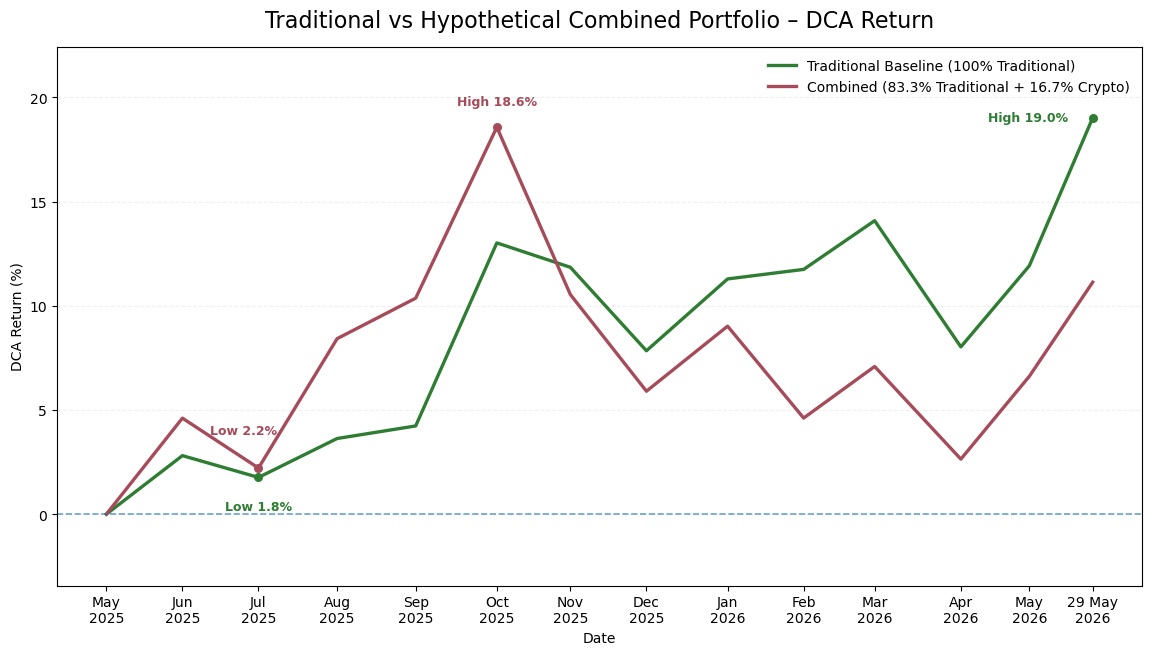

In [31]:
# Baseline: 600 units per month in traditional assets
traditional_baseline = traditional_common_dca.copy()

traditional_baseline["Invested"] *= 6
traditional_baseline["Portfolio_Value"] *= 6

traditional_baseline["Profit_Loss"] = (
    traditional_baseline["Portfolio_Value"]
    - traditional_baseline["Invested"]
)

traditional_baseline["Return (%)"] = (
    traditional_baseline["Profit_Loss"]
    / traditional_baseline["Invested"]
) * 100

# Crypto series on the same common observation dates
crypto_baseline = crypto_common_dca.copy()

# Combined: 500 traditional + 100 crypto = 600 total units per month
combined_dca = pd.DataFrame(
    index=common_observation_dates
)

combined_dca["Invested"] = (
    traditional_common_dca["Invested"] * 5
    + crypto_common_dca["Invested"]
)

combined_dca["Portfolio_Value"] = (
    traditional_common_dca["Portfolio_Value"] * 5
    + crypto_common_dca["Portfolio_Value"]
)

combined_dca["Profit_Loss"] = (
    combined_dca["Portfolio_Value"]
    - combined_dca["Invested"]
)

combined_dca["Return (%)"] = (
    combined_dca["Profit_Loss"]
    / combined_dca["Invested"]
) * 100

# Add final valuation rows to display copies only
traditional_baseline_display = traditional_baseline.copy()
combined_display_dca = combined_dca.copy()

traditional_baseline_final_invested = traditional_baseline["Invested"].iloc[-1]
traditional_baseline_final_value = traditional_final_value * 6

combined_final_invested = combined_dca["Invested"].iloc[-1]
combined_final_value = (
    traditional_final_value * 5
    + crypto_final_value
)

traditional_baseline_display.loc[final_valuation_date] = {
    "Invested": traditional_baseline_final_invested,
    "Portfolio_Value": traditional_baseline_final_value,
    "Profit_Loss": (
        traditional_baseline_final_value
        - traditional_baseline_final_invested
    ),
    "Return (%)": (
        (traditional_baseline_final_value - traditional_baseline_final_invested)
        / traditional_baseline_final_invested
    ) * 100
}

combined_display_dca.loc[final_valuation_date] = {
    "Invested": combined_final_invested,
    "Portfolio_Value": combined_final_value,
    "Profit_Loss": combined_final_value - combined_final_invested,
    "Return (%)": (
        (combined_final_value - combined_final_invested)
        / combined_final_invested
    ) * 100
}

traditional_baseline_display = traditional_baseline_display.sort_index()
combined_display_dca = combined_display_dca.sort_index()

# Display comparison table
return_comparison = pd.DataFrame({
    "Traditional Baseline Invested":
        traditional_baseline_display["Invested"],
    "Combined Portfolio Invested":
        combined_display_dca["Invested"],
    "Traditional Baseline Return (%)":
        traditional_baseline_display["Return (%)"],
    "Hypothetical Combined Return (%)":
        combined_display_dca["Return (%)"]
})

display(return_comparison.round(2))

# Plot both portfolios
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    traditional_baseline_display.index,
    traditional_baseline_display["Return (%)"],
    linewidth=2.4,
    color=portfolio_colors["Traditional"],
    label="Traditional Baseline (100% Traditional)"
)

ax.plot(
    combined_display_dca.index,
    combined_display_dca["Return (%)"],
    linewidth=2.4,
    color=portfolio_colors["Combined"],
    label="Combined (83.3% Traditional + 16.7% Crypto)"
)

# Find highs and lows, excluding the initial 0% point
traditional_after_start = (
    traditional_baseline_display["Return (%)"].iloc[1:]
)

combined_after_start = (
    combined_display_dca["Return (%)"].iloc[1:]
)

traditional_high_date = traditional_after_start.idxmax()
traditional_low_date = traditional_after_start.idxmin()

traditional_high = traditional_after_start.max()
traditional_low = traditional_after_start.min()

combined_high_date = combined_after_start.idxmax()
combined_low_date = combined_after_start.idxmin()

combined_high = combined_after_start.max()
combined_low = combined_after_start.min()

# Small filled high points
ax.scatter(
    traditional_high_date,
    traditional_high,
    s=30,
    color=portfolio_colors["Traditional"],
    zorder=5
)

ax.scatter(
    combined_high_date,
    combined_high,
    s=30,
    color=portfolio_colors["Combined"],
    zorder=5
)

# Small filled low points
ax.scatter(
    traditional_low_date,
    traditional_low,
    s=30,
    color=portfolio_colors["Traditional"],
    zorder=6
)

ax.scatter(
    combined_low_date,
    combined_low,
    s=30,
    color=portfolio_colors["Combined"],
    zorder=6
)

# Traditional high -> left of the final point
ax.annotate(
    f"High {traditional_high:.1f}%",
    (traditional_high_date, traditional_high),
    xytext=(-18, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    fontsize=9,
    color=portfolio_colors["Traditional"],
    fontweight="bold"
)

# Combined high
ax.annotate(
    f"High {combined_high:.1f}%",
    (combined_high_date, combined_high),
    xytext=(0, 14),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=9,
    color=portfolio_colors["Combined"],
    fontweight="bold"
)

# Combined low (red) -> ABOVE, higher so it does not sit on the line
ax.annotate(
    f"Low {combined_low:.1f}%",
    (combined_low_date, combined_low),
    xytext=(-11, 22),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=9,
    color=portfolio_colors["Combined"],
    fontweight="bold"
)

# Traditional low (green) -> BELOW
ax.annotate(
    f"Low {traditional_low:.1f}%",
    (traditional_low_date, traditional_low),
    xytext=(0, -16),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=9,
    color=portfolio_colors["Traditional"],
    fontweight="bold"
)

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional vs Hypothetical Combined Portfolio – DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("DCA Return (%)")

ax.set_xticks(combined_display_dca.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in combined_display_dca.index
    ]
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.margins(y=0.18)

plt.show()


## 24. Gold Diversification Analysis

This section examines the diversification role of Gold from two perspectives.

### Gold and Bitcoin Diversification Test

Gold and Bitcoin each receive 10 normalized units per month. This hypothetical comparison tests whether equal monthly contributions to Gold and Bitcoin could reduce fluctuations compared with Bitcoin alone under the same systematic DCA schedule.

Both holdings are valued on the same monthly observation dates, with the common final valuation date of 29 May 2026 added as the last displayed observation without a new contribution. The Bitcoin component represents the simulated DCA strategy rather than actual cryptocurrency transactions.


In [32]:
# Monthly purchase prices
monthly_investment = 10

gold_purchase_prices = close_prices[
    "iShares_Physical_Gold_ETC"
].copy()

bitcoin_purchase_prices = crypto_close_prices[
    "Bitcoin"
].copy()

# Calculate units purchased at the actual monthly purchase prices
gold_units = monthly_investment / gold_purchase_prices
bitcoin_units = monthly_investment / bitcoin_purchase_prices

# Calculate cumulative holdings
gold_cumulative_units = gold_units.cumsum()
bitcoin_cumulative_units = bitcoin_units.cumsum()

# Observe both assets on the same common dates
gold_common_prices = pd.Series(
    [
        traditional_daily.loc[
            date,
            "iShares_Physical_Gold_ETC"
        ]
        for date in common_observation_dates
    ],
    index=common_observation_dates,
    name="Gold"
)

bitcoin_common_prices = pd.Series(
    [
        crypto_daily.loc[date, "Bitcoin"]
        for date in common_observation_dates
    ],
    index=common_observation_dates,
    name="Bitcoin"
)

# Value cumulative holdings on the common observation dates
gold_value = pd.Series(
    gold_cumulative_units.to_numpy()
    * gold_common_prices.to_numpy(),
    index=common_observation_dates
)

bitcoin_value = pd.Series(
    bitcoin_cumulative_units.to_numpy()
    * bitcoin_common_prices.to_numpy(),
    index=common_observation_dates
)

# Cumulative invested amounts
invested_single = pd.Series(
    range(1, len(common_observation_dates) + 1),
    index=common_observation_dates,
    dtype=float
) * monthly_investment

# Calculate individual DCA returns
gold_return = (
    (gold_value - invested_single)
    / invested_single
) * 100

bitcoin_return = (
    (bitcoin_value - invested_single)
    / invested_single
) * 100

# Combine Gold and Bitcoin with equal monthly contributions
gold_bitcoin_value = gold_value + bitcoin_value
gold_bitcoin_invested = invested_single * 2

gold_bitcoin_return = (
    (gold_bitcoin_value - gold_bitcoin_invested)
    / gold_bitcoin_invested
) * 100

# Combine results
gold_bitcoin_comparison = pd.DataFrame({
    "Gold": gold_return,
    "Bitcoin": bitcoin_return,
    "Gold + Bitcoin": gold_bitcoin_return
})

# Add the common final valuation date without a new contribution
gold_final_value = (
    gold_cumulative_units.iloc[-1]
    * traditional_daily.loc[
        final_valuation_date,
        "iShares_Physical_Gold_ETC"
    ]
)

bitcoin_final_value = (
    bitcoin_cumulative_units.iloc[-1]
    * crypto_daily.loc[
        final_valuation_date,
        "Bitcoin"
    ]
)

final_invested_single = invested_single.iloc[-1]

gold_final_return = (
    (gold_final_value - final_invested_single)
    / final_invested_single
) * 100

bitcoin_final_return = (
    (bitcoin_final_value - final_invested_single)
    / final_invested_single
) * 100

gold_bitcoin_final_return = (
    (
        gold_final_value
        + bitcoin_final_value
        - final_invested_single * 2
    )
    / (final_invested_single * 2)
) * 100

gold_bitcoin_comparison.loc[final_valuation_date] = {
    "Gold": gold_final_return,
    "Bitcoin": bitcoin_final_return,
    "Gold + Bitcoin": gold_bitcoin_final_return
}

gold_bitcoin_comparison = gold_bitcoin_comparison.sort_index()

gold_bitcoin_comparison


,Gold,Bitcoin,Gold + Bitcoin
Observation_Date,,,
2025-05-05,0.000000,0.000000,0.000000
2025-06-04,0.399822,4.742556,2.571189
2025-07-04,-2.545919,3.176059,0.315070
2025-08-04,0.378592,8.797159,4.587875
2025-09-04,3.824495,3.236671,3.530583
2025-10-06,12.526606,13.159772,12.843189
2025-11-04,13.069819,-5.191292,3.939263
2025-12-04,15.961326,-13.274322,1.343502
2026-01-05,19.239611,-10.820898,4.209357


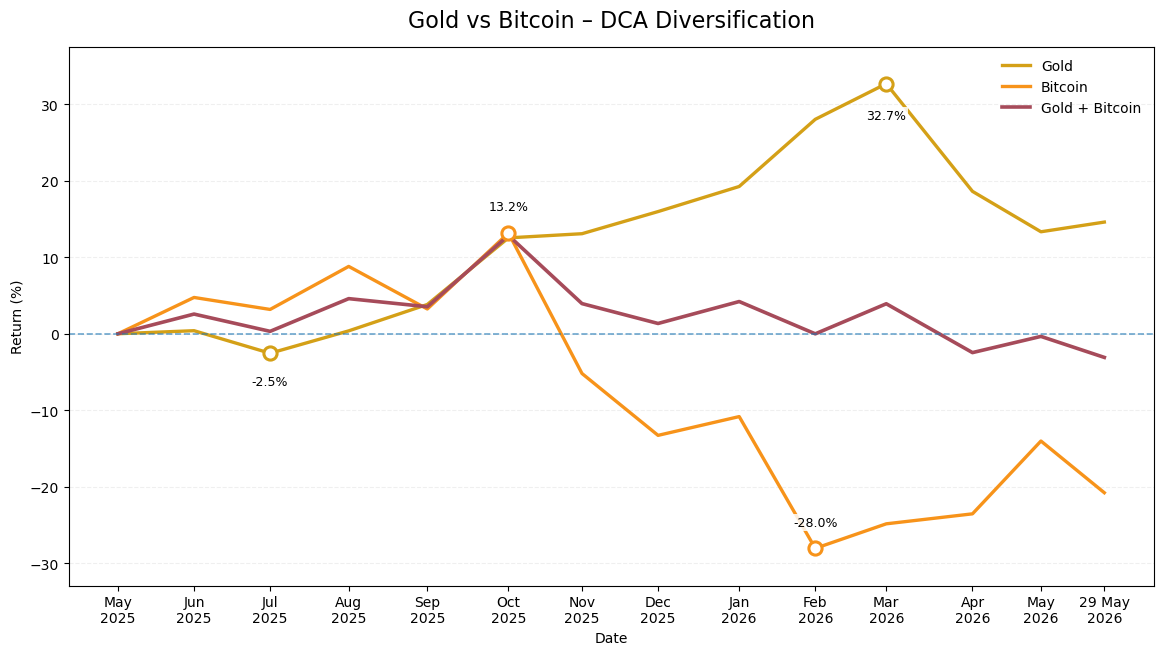

In [33]:
# Plot Gold, Bitcoin, and combined DCA returns
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    gold_bitcoin_comparison.index,
    gold_bitcoin_comparison["Gold"],
    linewidth=2.4,
    color=asset_colors["iShares_Physical_Gold_ETC"],
    label="Gold"
)

ax.plot(
    gold_bitcoin_comparison.index,
    gold_bitcoin_comparison["Bitcoin"],
    linewidth=2.4,
    color=crypto_colors["Bitcoin"],
    label="Bitcoin"
)

ax.plot(
    gold_bitcoin_comparison.index,
    gold_bitcoin_comparison["Gold + Bitcoin"],
    linewidth=2.6,
    color=portfolio_colors["Combined"],
    label="Gold + Bitcoin"
)

# Exclude the initial 0% starting point
gold_returns = gold_bitcoin_comparison["Gold"].iloc[1:]
bitcoin_returns = gold_bitcoin_comparison["Bitcoin"].iloc[1:]

# Find high and low points
gold_high_date = gold_returns.idxmax()
gold_low_date = gold_returns.idxmin()

bitcoin_high_date = bitcoin_returns.idxmax()
bitcoin_low_date = bitcoin_returns.idxmin()

highlight_points = [
    ("Gold", gold_high_date, gold_returns.loc[gold_high_date]),
    ("Gold", gold_low_date, gold_returns.loc[gold_low_date]),
    ("Bitcoin", bitcoin_high_date, bitcoin_returns.loc[bitcoin_high_date]),
    ("Bitcoin", bitcoin_low_date, bitcoin_returns.loc[bitcoin_low_date])
]

# Highlight high and low points
for asset, date, value in highlight_points:

    color = (
        asset_colors["iShares_Physical_Gold_ETC"]
        if asset == "Gold"
        else crypto_colors["Bitcoin"]
    )

    ax.scatter(
        date,
        value,
        s=90,
        facecolor="white",
        edgecolor=color,
        linewidth=2.2,
        zorder=5
    )

    # Keep labels inside the chart
    if asset == "Gold" and date == gold_low_date:
        offset = -16
        vertical_alignment = "top"
    elif value >= 30:
        offset = -18
        vertical_alignment = "top"
    elif value <= -20:
        offset = 14
        vertical_alignment = "bottom"
    else:
        offset = 14
        vertical_alignment = "bottom"

    ax.annotate(
        f"{value:.1f}%",
        (date, value),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=9,
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.2
        )
    )

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Gold vs Bitcoin – DCA Diversification",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")

# Show every month
ax.set_xticks(gold_bitcoin_comparison.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in gold_bitcoin_comparison.index
    ]
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.legend(
    frameon=False
)

ax.margins(y=0.08)

plt.show()


### Gold's Role in the Traditional Portfolio

Gold represents 10% of the monthly investment allocation in the traditional portfolio.

This analysis compares the traditional portfolio with its Gold allocation against a hypothetical version in which the 10% Gold share is removed and redistributed proportionally across the remaining traditional assets. Both versions therefore invest the same normalized amount each month.

The chart shows the monthly purchase-date observations and adds the common final valuation date of 29 May 2026 as the last point without a new contribution. The objective is to evaluate whether Gold reduced portfolio fluctuations or influenced overall performance during the analyzed period.


,With Gold (%),Without Gold (%)
Purchase_Date,,
2025-05-05,0.00,0.00
2025-06-04,2.81,3.08
2025-07-04,1.76,2.24
2025-08-04,3.63,3.99
2025-09-04,4.23,4.28
2025-10-06,13.02,13.07
2025-11-04,11.85,11.71
2025-12-04,7.84,6.94
2026-01-05,11.29,10.40


,Portfolio,Valuation Date,Final DCA Return (%)
0,Traditional Portfolio With Gold,2026-05-29,19.02
1,Traditional Portfolio Without Gold,2026-05-29,19.51


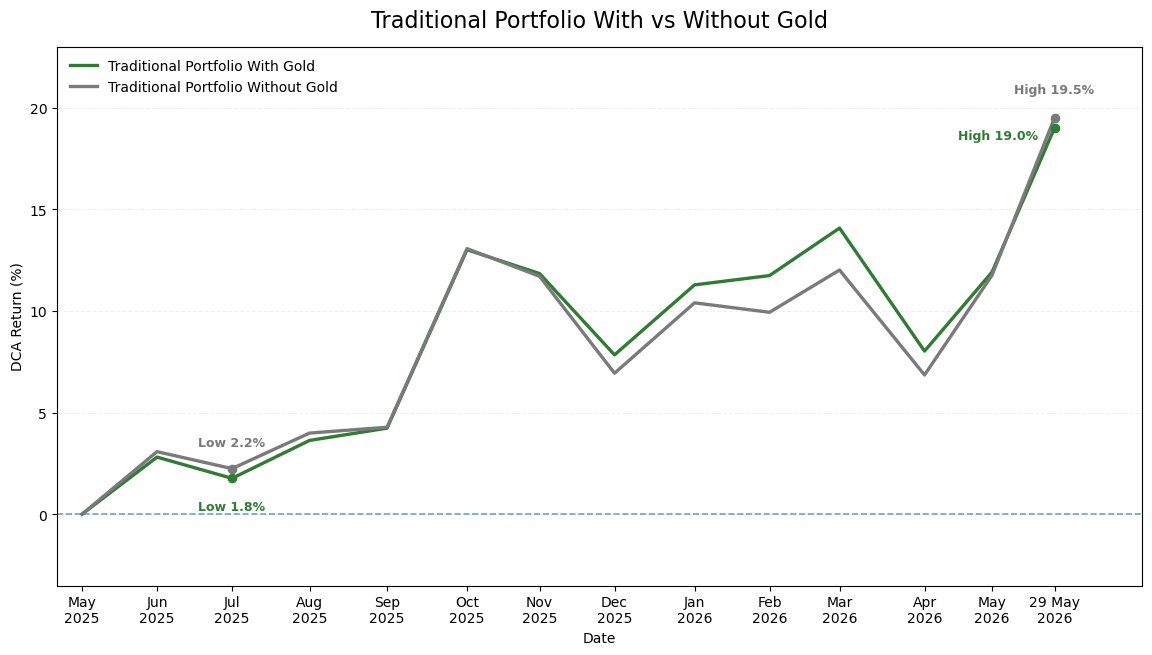

In [34]:
# Define Gold asset
gold_asset = "iShares_Physical_Gold_ETC"

# Gold allocation in the actual traditional portfolio
gold_allocation = traditional_allocation[gold_asset]

# Create hypothetical allocation without Gold
# Remaining assets are proportionally rescaled to 100%
without_gold_allocation = {
    asset: allocation / (100 - gold_allocation) * 100
    for asset, allocation in traditional_allocation.items()
    if asset != gold_asset
}

# Calculate monthly units purchased for the portfolio without Gold
without_gold_units_purchased = close_prices[
    list(without_gold_allocation.keys())
].copy()

for asset, allocation in without_gold_allocation.items():
    without_gold_units_purchased[asset] = (
        allocation / close_prices[asset]
    )

# Calculate cumulative holdings
without_gold_cumulative_units = (
    without_gold_units_purchased.cumsum()
)

# Calculate portfolio value at each traditional purchase date
without_gold_asset_values = (
    without_gold_cumulative_units
    * close_prices[list(without_gold_allocation.keys())]
)

without_gold_portfolio_value = (
    without_gold_asset_values.sum(axis=1)
)

# Same normalized monthly investment as the actual portfolio
without_gold_invested = pd.Series(
    range(1, len(close_prices) + 1),
    index=close_prices.index
) * 100

# Build hypothetical portfolio without Gold
without_gold_dca = pd.DataFrame({
    "Invested": without_gold_invested,
    "Portfolio_Value": without_gold_portfolio_value
})

without_gold_dca["Profit_Loss"] = (
    without_gold_dca["Portfolio_Value"]
    - without_gold_dca["Invested"]
)

without_gold_dca["Return (%)"] = (
    without_gold_dca["Profit_Loss"]
    / without_gold_dca["Invested"]
) * 100

# Final valuation on the same common final market date
with_gold_final_value = (
    traditional_cumulative_units.iloc[-1]
    * traditional_daily.loc[
        final_valuation_date,
        traditional_cumulative_units.columns
    ]
).sum()

without_gold_final_value = (
    without_gold_cumulative_units.iloc[-1]
    * traditional_daily.loc[
        final_valuation_date,
        without_gold_cumulative_units.columns
    ]
).sum()

final_invested = traditional_invested.iloc[-1]

with_gold_final_return = (
    (with_gold_final_value - final_invested)
    / final_invested
) * 100

without_gold_final_return = (
    (without_gold_final_value - final_invested)
    / final_invested
) * 100

# Compare monthly DCA returns and include final valuation
with_gold_display_dca = traditional_dca.copy()
without_gold_display_dca = without_gold_dca.copy()

with_gold_display_dca.loc[final_valuation_date] = {
    "Invested": final_invested,
    "Portfolio_Value": with_gold_final_value,
    "Profit_Loss": with_gold_final_value - final_invested,
    "Return (%)": with_gold_final_return
}

without_gold_display_dca.loc[final_valuation_date] = {
    "Invested": final_invested,
    "Portfolio_Value": without_gold_final_value,
    "Profit_Loss": without_gold_final_value - final_invested,
    "Return (%)": without_gold_final_return
}

with_gold_display_dca = with_gold_display_dca.sort_index()
without_gold_display_dca = without_gold_display_dca.sort_index()

# Comparison table
gold_portfolio_comparison = pd.DataFrame({
    "With Gold (%)":
        with_gold_display_dca["Return (%)"],
    "Without Gold (%)":
        without_gold_display_dca["Return (%)"]
})

display(gold_portfolio_comparison.round(2))

# Final summary
gold_effect_summary = pd.DataFrame({
    "Portfolio": [
        "Traditional Portfolio With Gold",
        "Traditional Portfolio Without Gold"
    ],
    "Valuation Date": [
        final_valuation_date,
        final_valuation_date
    ],
    "Final DCA Return (%)": [
        with_gold_final_return,
        without_gold_final_return
    ]
})

display(gold_effect_summary.round(2))

# Plot monthly comparison plus final valuation
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    with_gold_display_dca.index,
    with_gold_display_dca["Return (%)"],
    linewidth=2.4,
    color=portfolio_colors["Traditional"],
    label="Traditional Portfolio With Gold"
)

ax.plot(
    without_gold_display_dca.index,
    without_gold_display_dca["Return (%)"],
    linewidth=2.4,
    color="#7A7A7A",
    label="Traditional Portfolio Without Gold"
)

# Exclude starting month when identifying highs and lows
with_gold_after_start = with_gold_display_dca["Return (%)"].iloc[1:]
without_gold_after_start = without_gold_display_dca["Return (%)"].iloc[1:]

# High and low – With Gold
with_gold_high_date = with_gold_after_start.idxmax()
with_gold_low_date = with_gold_after_start.idxmin()
with_gold_high = with_gold_after_start.max()
with_gold_low = with_gold_after_start.min()

# High and low – Without Gold
without_gold_high_date = without_gold_after_start.idxmax()
without_gold_low_date = without_gold_after_start.idxmin()
without_gold_high = without_gold_after_start.max()
without_gold_low = without_gold_after_start.min()

# Small filled points
ax.scatter(
    with_gold_high_date,
    with_gold_high,
    s=35,
    color=portfolio_colors["Traditional"],
    zorder=7
)

ax.scatter(
    with_gold_low_date,
    with_gold_low,
    s=35,
    color=portfolio_colors["Traditional"],
    zorder=7
)

ax.scatter(
    without_gold_high_date,
    without_gold_high,
    s=35,
    color="#7A7A7A",
    zorder=7
)

ax.scatter(
    without_gold_low_date,
    without_gold_low,
    s=35,
    color="#7A7A7A",
    zorder=7
)

# ----- LABELS -----

# Gray high -> directly above the gray point
ax.annotate(
    f"High {without_gold_high:.1f}%",
    (without_gold_high_date, without_gold_high),
    xytext=(0, 16),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#7A7A7A",
    fontweight="bold"
)

# High label – With Gold (green) -> left and slightly below
ax.annotate(
    f"High {with_gold_high:.1f}%",
    (with_gold_high_date, with_gold_high),
    xytext=(-12, -1),
    textcoords="offset points",
    ha="right",
    va="top",
    fontsize=9,
    color=portfolio_colors["Traditional"],
    fontweight="bold"
)

# Gray low -> above
ax.annotate(
    f"Low {without_gold_low:.1f}%",
    (without_gold_low_date, without_gold_low),
    xytext=(0, 14),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#7A7A7A",
    fontweight="bold"
)

# Green low -> below
ax.annotate(
    f"Low {with_gold_low:.1f}%",
    (with_gold_low_date, with_gold_low),
    xytext=(0, -16),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=9,
    color=portfolio_colors["Traditional"],
    fontweight="bold"
)

# Zero return reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional Portfolio With vs Without Gold",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Date")
ax.set_ylabel("DCA Return (%)")

ax.set_xticks(with_gold_display_dca.index)
ax.set_xticklabels(
    [
        date.strftime("%d %b\n%Y")
        if date == final_valuation_date
        else date.strftime("%b\n%Y")
        for date in with_gold_display_dca.index
    ]
)

# little extra space on right side
ax.set_xlim(
    with_gold_display_dca.index.min() - pd.Timedelta(days=10),
    final_valuation_date + pd.Timedelta(days=35)
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.margins(y=0.18)

plt.show()

## 25. Calculate Monthly Portfolio Returns

Monthly returns measure portfolio performance between two consecutive common observation dates while excluding the effect of the new monthly contribution.

Traditional, simulated cryptocurrency, and hypothetical combined portfolios are valued on the same monthly dates for this comparison. These monthly returns are different from the cumulative DCA returns calculated earlier.

In [35]:
# Calculate monthly traditional portfolio returns
traditional_monthly_return = (
    (traditional_baseline["Portfolio_Value"] - 600)
    / traditional_baseline["Portfolio_Value"].shift(1)
) - 1

# Calculate monthly simulated crypto returns
crypto_monthly_return = (
    (crypto_baseline["Portfolio_Value"] - 100)
    / crypto_baseline["Portfolio_Value"].shift(1)
) - 1

# Calculate monthly hypothetical combined returns
combined_monthly_return = (
    (combined_dca["Portfolio_Value"] - 600)
    / combined_dca["Portfolio_Value"].shift(1)
) - 1

# All three series already use the same common observation dates
monthly_returns = pd.DataFrame({
    "Traditional": traditional_monthly_return,
    "Crypto": crypto_monthly_return,
    "Combined": combined_monthly_return
})

# Display as percentages
display((monthly_returns * 100).round(2))

,Traditional,Crypto,Combined
Observation_Date,,,
2025-05-05,NaN,NaN,NaN
2025-06-04,5.62,27.21,9.22
2025-07-04,-0.16,-6.08,-1.23
2025-08-04,3.02,37.05,8.82
2025-09-04,1.60,14.28,4.18
2025-10-06,10.92,10.33,10.80
2025-11-04,0.71,-28.47,-5.29
2025-12-04,-2.58,-8.02,-3.43
2026-01-05,4.50,1.25,4.01


## 26. Portfolio Performance and Risk Metrics

Monthly returns are used to calculate key performance and risk metrics for the traditional, simulated cryptocurrency, and hypothetical combined portfolios.

The Sharpe ratio uses a simplified risk-free rate of 0%.

In [36]:
# Remove the first month with no previous return
returns = monthly_returns.dropna()

# Average monthly return
average_monthly_return = returns.mean()

# Annualized return
annualized_return = (
    (1 + returns).prod() ** (12 / len(returns))
    - 1
)

# Annualized volatility
annualized_volatility = (
    returns.std() * (12 ** 0.5)
)

# Sharpe ratio with 0% risk-free rate
sharpe_ratio = (
    returns.mean() * 12
    / annualized_volatility
)

# Calculate maximum drawdown
growth = (1 + returns).cumprod()
running_max = growth.cummax()
drawdown = growth / running_max - 1
max_drawdown = drawdown.min()

# Create summary table
performance_metrics = pd.DataFrame({
    "Average Monthly Return (%)": average_monthly_return * 100,
    "Annualized Return (%)": annualized_return * 100,
    "Annualized Volatility (%)": annualized_volatility * 100,
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown (%)": max_drawdown * 100
})

performance_metrics.round(2)

,Average Monthly Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Traditional,2.37,31.33,13.96,2.04,-4.67
Crypto,1.72,-2.10,69.32,0.30,-55.34
Combined,2.25,28.47,19.55,1.38,-9.19


## 27. Individual Asset DCA Performance

Each traditional asset is analyzed separately to compare its final DCA performance over the investment period.

The analysis shows the normalized amount invested, final value, profit or loss, and DCA return for each asset.

In [37]:
# Use the common final market date defined earlier
print("Final valuation date:", final_valuation_date)

# Calculate final DCA performance for each traditional asset
traditional_asset_results = []

for asset, allocation in traditional_allocation.items():

    invested = allocation * len(close_prices)

    final_units = traditional_cumulative_units[asset].iloc[-1]

    final_price = traditional_daily.loc[
        final_valuation_date,
        asset
    ]

    final_value = final_units * final_price

    profit_loss = final_value - invested

    return_pct = (
        profit_loss / invested
    ) * 100

    traditional_asset_results.append({
        "Asset": asset,
        "Invested": invested,
        "Final Value": final_value,
        "Profit/Loss": profit_loss,
        "DCA Return (%)": return_pct
    })

traditional_asset_performance = pd.DataFrame(
    traditional_asset_results
)

traditional_asset_performance = (
    traditional_asset_performance
    .sort_values("DCA Return (%)", ascending=False)
    .reset_index(drop=True)
)

traditional_asset_performance.assign(
    DisplayName=traditional_asset_performance["Asset"]
    .map(display_names)
    .fillna(traditional_asset_performance["Asset"])
)[
    [
        "DisplayName",
        "Invested",
        "Final Value",
        "Profit/Loss",
        "DCA Return (%)"
    ]
].round(2)

Final valuation date: 2026-05-29 00:00:00


,DisplayName,Invested,Final Value,Profit/Loss,DCA Return (%)
0,ASML Holding,65,107.60,42.60,65.53
1,L&G Artificial Intelligence,130,191.40,61.40,47.23
2,Amundi Nasdaq 100,195,245.49,50.49,25.89
3,Scalable MSCI AC World,390,455.01,65.01,16.67
4,iShares Physical Gold ETC,130,148.97,18.97,14.59
5,VanEck Defense,325,348.42,23.42,7.21
6,Rheinmetall,65,50.34,-14.66,-22.56


In [38]:
# Calculate final simulated DCA performance for each cryptocurrency
crypto_asset_results = []

for asset, allocation in crypto_allocation.items():

    invested = allocation * len(crypto_close_prices)

    final_units = crypto_cumulative_units[asset].iloc[-1]

    final_price = crypto_daily.loc[
        final_valuation_date,
        asset
    ]

    final_value = final_units * final_price

    profit_loss = final_value - invested

    return_pct = (
        profit_loss / invested
    ) * 100

    crypto_asset_results.append({
        "Asset": asset,
        "Invested": invested,
        "Final Value": final_value,
        "Profit/Loss": profit_loss,
        "DCA Return (%)": return_pct
    })

crypto_asset_performance = pd.DataFrame(
    crypto_asset_results
)

crypto_asset_performance = (
    crypto_asset_performance
    .sort_values("DCA Return (%)", ascending=False)
    .reset_index(drop=True)
)

crypto_asset_performance.round(2)

,Asset,Invested,Final Value,Profit/Loss,DCA Return (%)
0,Bitcoin,130,103.00,-27.00,-20.77
1,Ethereum,780,578.46,-201.54,-25.84
2,Solana,390,250.70,-139.30,-35.72


## 28. Gold and Bitcoin Risk Comparison

Monthly price returns are used to compare the volatility and correlation of Gold and Bitcoin on the same common observation dates used in the diversification test.

This helps evaluate whether Gold provided diversification benefits relative to Bitcoin during the analyzed period.

These observation-date volatility figures may differ slightly from the month-end volatility reported in the traditional asset risk metrics.

In [39]:
# Calculate monthly price returns on common observation dates
gold_monthly_returns = gold_common_prices.pct_change().dropna()
bitcoin_monthly_returns = bitcoin_common_prices.pct_change().dropna()

# Align both series
gold_bitcoin_monthly_returns = pd.DataFrame({
    "Gold": gold_monthly_returns,
    "Bitcoin": bitcoin_monthly_returns
}).dropna()

# Annualized volatility
gold_volatility = (
    gold_bitcoin_monthly_returns["Gold"].std()
    * (12 ** 0.5)
)

bitcoin_volatility = (
    gold_bitcoin_monthly_returns["Bitcoin"].std()
    * (12 ** 0.5)
)

# Correlation
gold_bitcoin_correlation = (
    gold_bitcoin_monthly_returns["Gold"]
    .corr(gold_bitcoin_monthly_returns["Bitcoin"])
)

gold_bitcoin_risk = pd.DataFrame({
    "Annualized Volatility (%)": [
        gold_volatility * 100,
        bitcoin_volatility * 100
    ]
}, index=["Gold", "Bitcoin"])

display(gold_bitcoin_risk.round(2))

print(
    "Gold–Bitcoin Correlation:",
    round(gold_bitcoin_correlation, 2)
)

,Annualized Volatility (%)
Gold,20.26
Bitcoin,38.44


Gold–Bitcoin Correlation: -0.21


## 29. Traditional Asset DCA Return Comparison

The final DCA return of each traditional asset is compared independently of its portfolio weight.

This comparison shows which assets performed best or worst on a percentage basis over the investment period.

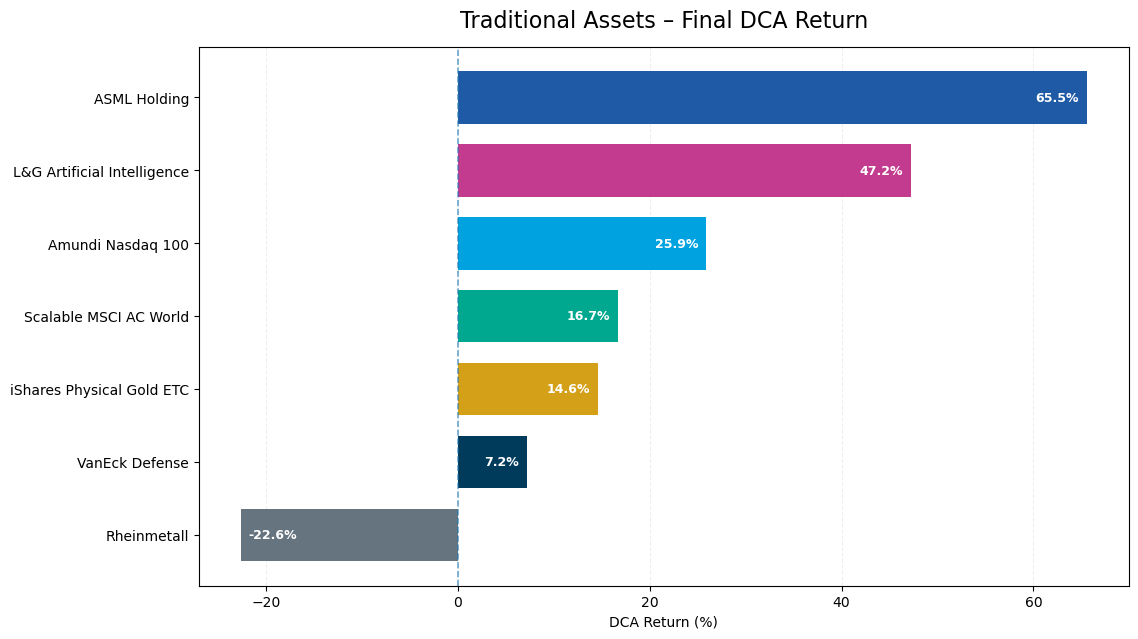

In [40]:
# Sort assets by DCA return
traditional_plot = traditional_asset_performance.sort_values(
    "DCA Return (%)"
).copy()

# Add readable asset names
traditional_plot["DisplayName"] = (
    traditional_plot["Asset"]
    .map(display_names)
    .fillna(traditional_plot["Asset"])
)

# Apply consistent asset colors
colors = [
    asset_colors[asset]
    for asset in traditional_plot["Asset"]
]

# Plot individual asset returns
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    traditional_plot["DisplayName"],
    traditional_plot["DCA Return (%)"],
    color=colors,
    height=0.72
)

# Add return values inside the bars
for bar, value in zip(
    bars,
    traditional_plot["DCA Return (%)"]
):
    if value >= 0:
        x_position = value - 0.8
        alignment = "right"
    else:
        x_position = value + 0.8
        alignment = "left"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha=alignment,
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# Zero return reference
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional Assets – Final DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("DCA Return (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

# Keep grid behind bars
ax.set_axisbelow(True)

plt.show()

## 30. Simulated Cryptocurrency Asset DCA Return Comparison

The final simulated DCA returns of Bitcoin, Ethereum, and Solana are compared using the same monthly investment schedule.

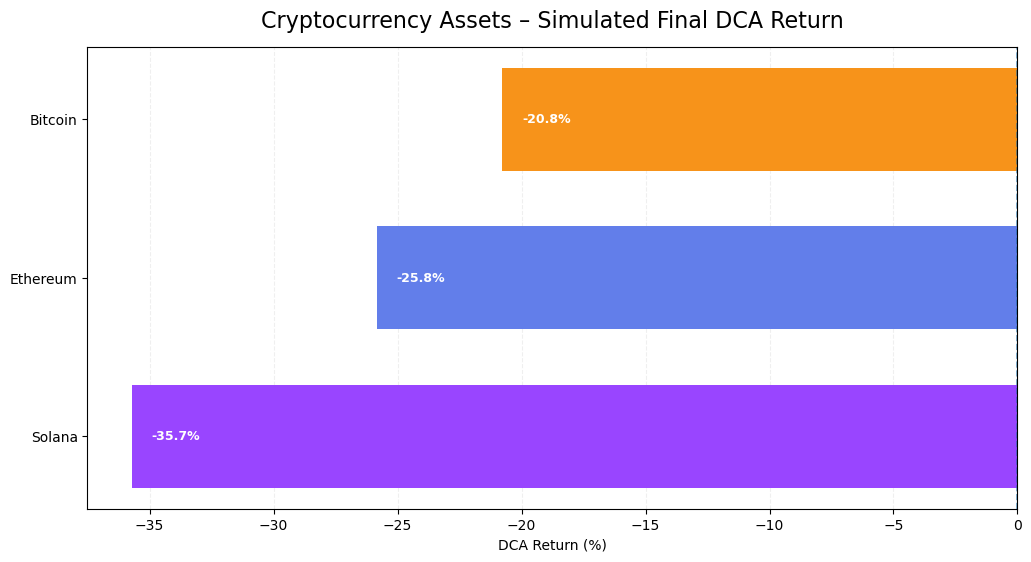

In [41]:
# Sort cryptocurrencies by DCA return
crypto_plot = crypto_asset_performance.sort_values(
    "DCA Return (%)"
)

# Apply consistent crypto colors
colors = [
    crypto_colors[asset]
    for asset in crypto_plot["Asset"]
]

# Plot individual crypto returns
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    crypto_plot["Asset"],
    crypto_plot["DCA Return (%)"],
    color=colors,
    height=0.65
)

# Add return values inside the bars
for bar, value in zip(
    bars,
    crypto_plot["DCA Return (%)"]
):
    if value >= 0:
        x_position = value - 0.8
        alignment = "right"
    else:
        x_position = value + 0.8
        alignment = "left"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha=alignment,
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# Zero return reference
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Cryptocurrency Assets – Simulated Final DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("DCA Return (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.set_axisbelow(True)

plt.show()

## 31. Traditional Asset Contribution Analysis

Asset returns alone do not show how strongly each position affected the portfolio because the assets have different allocation weights.

This analysis measures how much each traditional asset contributed to the final portfolio return.

Contributions are expressed in percentage points (pp), allowing positive and negative effects on the overall portfolio performance to be compared directly.

In [42]:
# Traditional asset contribution
traditional_contribution = traditional_asset_performance.copy()

traditional_total_invested = (
    traditional_contribution["Invested"].sum()
)

traditional_contribution["Monthly Investment Share (%)"] = (
    traditional_contribution["Invested"]
    / traditional_total_invested
) * 100

traditional_contribution["Contribution to Return (pp)"] = (
    traditional_contribution["Profit/Loss"]
    / traditional_total_invested
) * 100

traditional_contribution = (
    traditional_contribution
    .sort_values(
        "Contribution to Return (pp)",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add readable asset names
traditional_contribution["DisplayName"] = (
    traditional_contribution["Asset"]
    .map(display_names)
    .fillna(traditional_contribution["Asset"])
)

display(
    traditional_contribution[
        [
            "DisplayName",
            "Monthly Investment Share (%)",
            "DCA Return (%)",
            "Contribution to Return (pp)"
        ]
    ].round(2)
)

,DisplayName,Monthly Investment Share (%),DCA Return (%),Contribution to Return (pp)
0,Scalable MSCI AC World,30.0,16.67,5.00
1,L&G Artificial Intelligence,10.0,47.23,4.72
2,Amundi Nasdaq 100,15.0,25.89,3.88
3,ASML Holding,5.0,65.53,3.28
4,VanEck Defense,25.0,7.21,1.80
5,iShares Physical Gold ETC,10.0,14.59,1.46
6,Rheinmetall,5.0,-22.56,-1.13


## 32. Traditional Asset Risk Metrics

The traditional portfolio assets are compared using monthly market returns.

The analysis includes annualized return, annualized volatility, Sharpe ratio, and maximum drawdown. These metrics help compare return and risk across the individual holdings.

The Sharpe ratio uses a simplified risk-free rate of 0%.

In [43]:
# Calculate monthly returns for traditional assets
traditional_asset_returns = (
    traditional_daily
    .resample("ME")
    .last()
    .pct_change()
)

asset_metrics = []

for asset in traditional_asset_returns.columns:

    returns = traditional_asset_returns[asset].dropna()

    # Annualized return
    annualized_return = (
        (1 + returns).prod() ** (12 / len(returns))
        - 1
    )

    # Annualized volatility
    annualized_volatility = (
        returns.std() * (12 ** 0.5)
    )

    # Sharpe ratio
    sharpe_ratio = (
        returns.mean() * 12
        / annualized_volatility
    )

    # Maximum drawdown
    growth = (1 + returns).cumprod()
    running_max = growth.cummax()
    drawdown = growth / running_max - 1
    max_drawdown = drawdown.min()

    asset_metrics.append({
        "Asset": asset,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Volatility (%)": annualized_volatility * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown (%)": max_drawdown * 100
    })

individual_asset_metrics = pd.DataFrame(asset_metrics)

# Add readable asset names
individual_asset_metrics["DisplayName"] = (
    individual_asset_metrics["Asset"]
    .map(display_names)
    .fillna(individual_asset_metrics["Asset"])
)

individual_asset_metrics[
    [
        "DisplayName",
        "Annualized Return (%)",
        "Annualized Volatility (%)",
        "Sharpe Ratio",
        "Maximum Drawdown (%)"
    ]
].round(2)

,DisplayName,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
0,ASML Holding,111.46,45.59,1.88,-9.87
1,VanEck Defense,20.91,22.49,0.95,-9.02
2,Amundi Nasdaq 100,39.08,21.22,1.67,-9.62
3,iShares Physical Gold ETC,35.05,20.58,1.57,-11.42
4,Rheinmetall,-31.38,35.26,-0.89,-34.82
5,Scalable MSCI AC World,27.43,12.59,2.00,-5.31
6,L&G Artificial Intelligence,72.61,34.14,1.78,-15.43


## 33. Traditional Asset Correlation and Diversification

The correlation matrix compares the weekly returns of the assets in the traditional portfolio.

It helps identify which holdings tend to move together and which assets may provide diversification benefits within the actual portfolio.

Values close to +1 indicate similar movements, values close to 0 indicate little relationship, and negative values indicate movements in opposite directions.

In [44]:
# Resample traditional asset prices to weekly Friday data
traditional_weekly_prices = (
    traditional_daily
    .resample("W-FRI")
    .last()
)

# Calculate weekly returns
traditional_weekly_returns = (
    traditional_weekly_prices
    .pct_change()
    .dropna()
)

# Calculate correlation matrix
correlation_matrix = traditional_weekly_returns.corr()

correlation_display = correlation_matrix.rename(
    index=display_names,
    columns=display_names
)

# Display correlation values
display(correlation_display.round(2))

Ticker,ASML Holding,VanEck Defense,Amundi Nasdaq 100,iShares Physical Gold ETC,Rheinmetall,Scalable MSCI AC World,L&G Artificial Intelligence
Ticker,,,,,,,
ASML Holding,1.00,0.31,0.42,0.10,0.22,0.52,0.42
VanEck Defense,0.31,1.00,0.41,0.16,0.77,0.51,0.44
Amundi Nasdaq 100,0.42,0.41,1.00,-0.08,0.11,0.89,0.88
iShares Physical Gold ETC,0.10,0.16,-0.08,1.00,0.20,-0.02,-0.08
Rheinmetall,0.22,0.77,0.11,0.20,1.00,0.25,0.25
Scalable MSCI AC World,0.52,0.51,0.89,-0.02,0.25,1.00,0.80
L&G Artificial Intelligence,0.42,0.44,0.88,-0.08,0.25,0.80,1.00


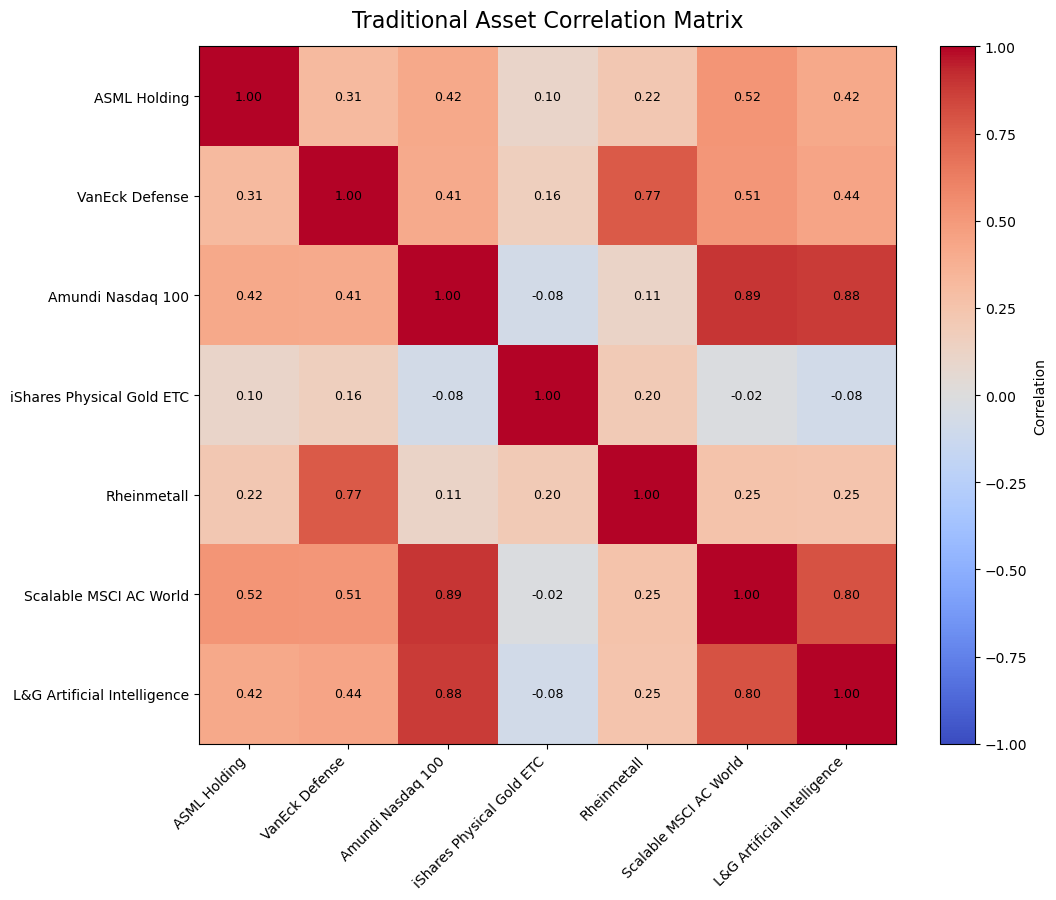

In [45]:
# Plot traditional asset correlation matrix
fig, ax = plt.subplots(figsize=(11, 9))

matrix = ax.imshow(
    correlation_display,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

# Axis labels
ax.set_xticks(range(len(correlation_display.columns)))
ax.set_yticks(range(len(correlation_display.columns)))

ax.set_xticklabels(
    correlation_display.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_display.columns
)

# Add correlation values
for i in range(len(correlation_display.columns)):
    for j in range(len(correlation_display.columns)):
        ax.text(
            j,
            i,
            f"{correlation_display.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title(
    "Traditional Asset Correlation Matrix",
    fontsize=16,
    pad=14
)

fig.colorbar(
    matrix,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()

## 34. Traditional Portfolio Benchmark Comparison

The traditional portfolio is compared with broad market benchmarks using the same monthly DCA schedule.

The comparison includes the iShares Core MSCI World, DAX, S&P 500, and Gold.

In [46]:
# Define benchmark assets
benchmark_tickers = {
    "iShares Core MSCI World": "EUNL.DE",
    "iShares Core DAX": "EXS1.DE",
    "iShares Core S&P 500": "SXR8.DE"
}
# Download benchmark market data
benchmark_data = yf.download(
    list(benchmark_tickers.values()),
    start="2025-05-01",
    end="2026-06-01",
    auto_adjust=False,
    progress=False
)

benchmark_data["Close"].head()

Ticker,EUNL.DE,EXS1.DE,SXR8.DE
Date,,,
2025-05-02,95.648003,191.779999,532.359985
2025-05-05,95.781998,193.860001,531.940002
2025-05-06,95.279999,193.199997,528.419983
2025-05-07,94.825996,192.139999,526.140015
2025-05-08,96.365997,194.000000,536.880005


In [47]:
# Match benchmark purchases with the next available trading day
benchmark_trading_dates = benchmark_data.index

benchmark_purchase_dates = purchase_schedule["Purchase_Date"].apply(
    lambda x: get_next_trading_day(x, benchmark_trading_dates)
)

# Extract benchmark purchase prices
benchmark_close_prices = benchmark_data["Close"].loc[
    benchmark_purchase_dates
].copy()

# Replace tickers with readable names
benchmark_ticker_to_name = {
    ticker: name
    for name, ticker in benchmark_tickers.items()
}

benchmark_close_prices = benchmark_close_prices.rename(
    columns=benchmark_ticker_to_name
)

# Use month as common comparison index
benchmark_close_prices.index = (
    benchmark_purchase_dates.values
)
benchmark_close_prices.index = (
    benchmark_close_prices.index.to_period("M")
)

# Add existing Gold purchase prices
gold_benchmark_prices = (
    close_prices["iShares_Physical_Gold_ETC"]
    .copy()
)

gold_benchmark_prices.index = (
    gold_benchmark_prices.index.to_period("M")
)

benchmark_close_prices["iShares Physical Gold ETC"] = gold_benchmark_prices

benchmark_close_prices

Ticker,iShares Core MSCI World,iShares Core DAX,iShares Core S&P 500,iShares Physical Gold ETC
2025-05,95.781998,193.860001,531.940002,56.900002
2025-06,100.089996,201.199997,557.799988,57.355000
2025-07,100.559998,197.199997,565.059998,54.945000
2025-08,103.019997,196.880005,582.200012,56.665001
2025-09,105.250000,196.899994,593.840027,59.150002
2025-10,109.239998,201.949997,615.280029,65.535004
2025-11,111.540001,198.399994,632.979980,67.120003
2025-12,111.339996,197.800003,628.919983,70.190002
2026-01,112.745003,205.850006,632.159973,73.629997
2026-02,112.699997,203.850006,626.640015,80.970001


In [48]:
# Calculate final DCA performance for each benchmark
benchmark_results = []

monthly_investment = 100
number_of_purchases = len(benchmark_close_prices)

for asset in [
    "iShares Core MSCI World",
    "iShares Core DAX",
    "iShares Core S&P 500"
]:

    # Calculate purchased and cumulative units
    units_purchased = (
        monthly_investment
        / benchmark_close_prices[asset]
    )

    cumulative_units = units_purchased.cumsum()

    # Final market price
    ticker = benchmark_tickers[asset]

    final_price = benchmark_data["Close"].loc[
        final_valuation_date,
        ticker
    ]

    # Final portfolio value
    final_value = (
        cumulative_units.iloc[-1]
        * final_price
    )

    invested = (
        monthly_investment
        * number_of_purchases
    )

    profit_loss = final_value - invested

    return_pct = (
        profit_loss / invested
    ) * 100

    benchmark_results.append({
        "Asset": asset,
        "Invested": invested,
        "Final Value": final_value,
        "Profit/Loss": profit_loss,
        "DCA Return (%)": return_pct
    })

# Calculate Gold benchmark
gold_units_purchased = (
    monthly_investment
    / benchmark_close_prices["iShares Physical Gold ETC"]
)

gold_cumulative_units = (
    gold_units_purchased.cumsum()
)

gold_final_price = traditional_daily.loc[
    final_valuation_date,
    "iShares_Physical_Gold_ETC"
]

gold_final_value = (
    gold_cumulative_units.iloc[-1]
    * gold_final_price
)

gold_invested = (
    monthly_investment
    * number_of_purchases
)

gold_profit_loss = (
    gold_final_value - gold_invested
)

gold_return_pct = (
    gold_profit_loss / gold_invested
) * 100

benchmark_results.append({
    "Asset": "iShares Physical Gold ETC",
    "Invested": gold_invested,
    "Final Value": gold_final_value,
    "Profit/Loss": gold_profit_loss,
    "DCA Return (%)": gold_return_pct
})

# Create comparison table
benchmark_performance = pd.DataFrame(
    benchmark_results
)

benchmark_performance = (
    benchmark_performance
    .sort_values("DCA Return (%)", ascending=False)
    .reset_index(drop=True)
)

benchmark_performance.round(2)

,Asset,Invested,Final Value,Profit/Loss,DCA Return (%)
0,iShares Core S&P 500,1300,1506.15,206.15,15.86
1,iShares Core MSCI World,1300,1491.44,191.44,14.73
2,iShares Physical Gold ETC,1300,1489.65,189.65,14.59
3,iShares Core DAX,1300,1356.51,56.51,4.35


In [49]:
# Add traditional portfolio to benchmark comparison
traditional_benchmark_row = pd.DataFrame({
    "Asset": ["Traditional Portfolio"],
    "Invested": [
        traditional_asset_performance["Invested"].sum()
    ],
    "Final Value": [
        traditional_asset_performance["Final Value"].sum()
    ],
    "Profit/Loss": [
        traditional_asset_performance["Profit/Loss"].sum()
    ],
    "DCA Return (%)": [
        (
            traditional_asset_performance["Profit/Loss"].sum()
            / traditional_asset_performance["Invested"].sum()
        ) * 100
    ]
})

benchmark_comparison = pd.concat(
    [
        benchmark_performance,
        traditional_benchmark_row
    ],
    ignore_index=True
)

benchmark_comparison = (
    benchmark_comparison
    .sort_values("DCA Return (%)", ascending=False)
    .reset_index(drop=True)
)

benchmark_comparison.round(2)

,Asset,Invested,Final Value,Profit/Loss,DCA Return (%)
0,Traditional Portfolio,1300,1547.22,247.22,19.02
1,iShares Core S&P 500,1300,1506.15,206.15,15.86
2,iShares Core MSCI World,1300,1491.44,191.44,14.73
3,iShares Physical Gold ETC,1300,1489.65,189.65,14.59
4,iShares Core DAX,1300,1356.51,56.51,4.35


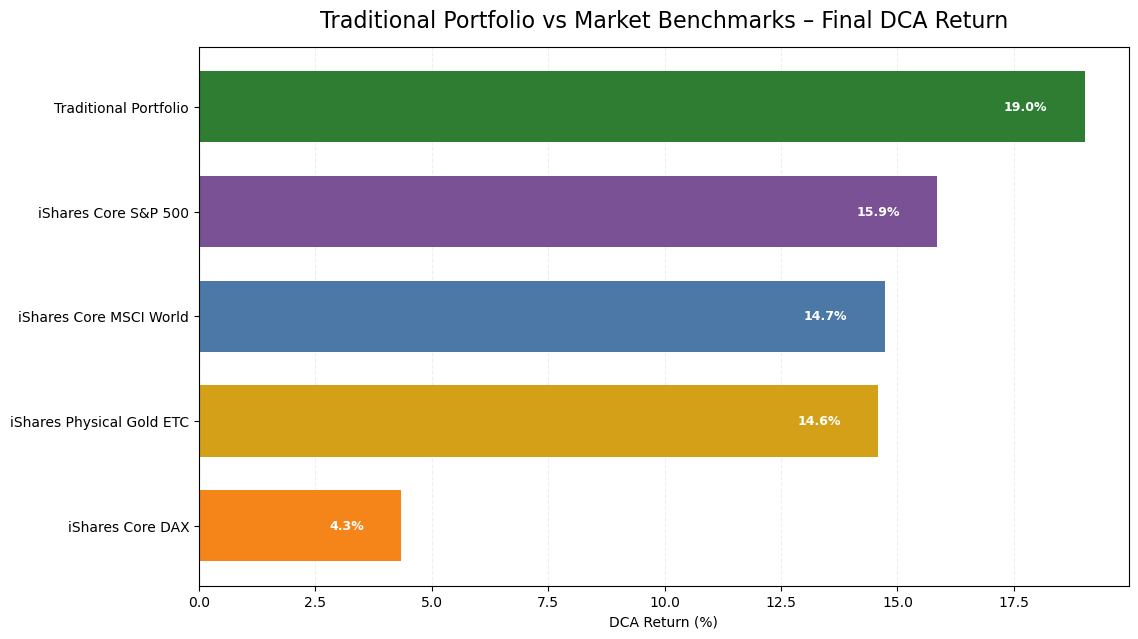

In [50]:
# Sort comparison by DCA return
benchmark_plot = benchmark_comparison.sort_values(
    "DCA Return (%)"
)

# Use predefined benchmark colors
colors = [
    benchmark_colors[asset]
    for asset in benchmark_plot["Asset"]
]

# Plot benchmark comparison
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    benchmark_plot["Asset"],
    benchmark_plot["DCA Return (%)"],
    color=colors,
    height=0.68
)

# Add return values inside bars
for bar, value in zip(
    bars,
    benchmark_plot["DCA Return (%)"]
):
    if value >= 0:
        x_position = value - 0.8
        alignment = "right"
    else:
        x_position = value + 0.8
        alignment = "left"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha=alignment,
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# Zero return reference
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Traditional Portfolio vs Market Benchmarks – Final DCA Return",
    fontsize=16,
    pad=14
)

ax.set_xlabel("DCA Return (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.set_axisbelow(True)

plt.show()

## 35. Monthly Investment Share vs Final Portfolio Weight

This analysis compares how each monthly investment was distributed across the traditional assets with each asset's final share of the portfolio.

The difference does not represent profit or loss. It shows how market performance changed the relative weight of each asset over time.

In [51]:
# Compare monthly investment share with final portfolio weight
allocation_comparison = traditional_asset_performance[
    ["Asset", "Final Value"]
].copy()

allocation_comparison["Monthly Investment Share (%)"] = (
    allocation_comparison["Asset"]
    .map(traditional_allocation)
)

allocation_comparison["Final Portfolio Weight (%)"] = (
    allocation_comparison["Final Value"]
    / allocation_comparison["Final Value"].sum()
) * 100

allocation_comparison["Change in Weight (pp)"] = (
    allocation_comparison["Final Portfolio Weight (%)"]
    - allocation_comparison["Monthly Investment Share (%)"]
)

# Add readable asset names
allocation_comparison["DisplayName"] = (
    allocation_comparison["Asset"]
    .map(display_names)
    .fillna(allocation_comparison["Asset"])
)

allocation_comparison[
    [
        "DisplayName",
        "Monthly Investment Share (%)",
        "Final Portfolio Weight (%)",
        "Change in Weight (pp)"
    ]
].round(2)

,DisplayName,Monthly Investment Share (%),Final Portfolio Weight (%),Change in Weight (pp)
0,ASML Holding,5,6.95,1.95
1,L&G Artificial Intelligence,10,12.37,2.37
2,Amundi Nasdaq 100,15,15.87,0.87
3,Scalable MSCI AC World,30,29.41,-0.59
4,iShares Physical Gold ETC,10,9.63,-0.37
5,VanEck Defense,25,22.52,-2.48
6,Rheinmetall,5,3.25,-1.75


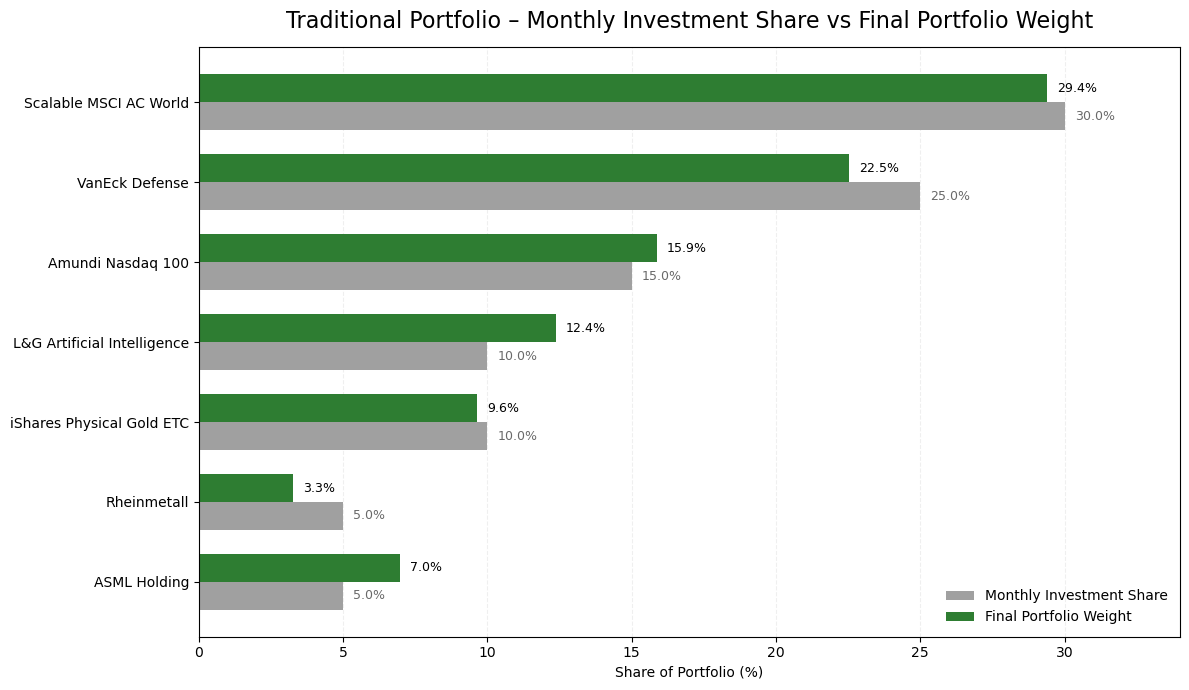

In [52]:
# Prepare allocation comparison for visualization
allocation_plot = allocation_comparison.copy()

# Use centralized readable asset names
allocation_plot["Asset"] = (
    allocation_plot["Asset"]
    .map(display_names)
    .fillna(allocation_plot["Asset"])
)

# Sort by monthly investment share
allocation_plot = allocation_plot.sort_values(
    "Monthly Investment Share (%)"
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

y = range(len(allocation_plot))
height = 0.35

# Monthly investment share
investment_bars = ax.barh(
    [i - height / 2 for i in y],
    allocation_plot["Monthly Investment Share (%)"],
    height=height,
    label="Monthly Investment Share",
    color="#A0A0A0"
)

# Final portfolio weight
final_bars = ax.barh(
    [i + height / 2 for i in y],
    allocation_plot["Final Portfolio Weight (%)"],
    height=height,
    label="Final Portfolio Weight",
    color=portfolio_colors["Traditional"]
)

# Add values for monthly investment share
for bar, value in zip(
    investment_bars,
    allocation_plot["Monthly Investment Share (%)"]
):
    ax.text(
        value + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        color="dimgray"
    )

# Add values for final portfolio weight
for bar, value in zip(
    final_bars,
    allocation_plot["Final Portfolio Weight (%)"]
):
    ax.text(
        value + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        color="black"
    )

# Axis labels
ax.set_yticks(list(y))
ax.set_yticklabels(allocation_plot["Asset"])

ax.set_xlabel("Share of Portfolio (%)")
ax.set_ylabel("")

# Title
ax.set_title(
    "Traditional Portfolio – Monthly Investment Share vs Final Portfolio Weight",
    fontsize=16,
    pad=14
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20
)

ax.legend(frameon=False)
ax.set_axisbelow(True)

# Add space for percentage labels
max_value = max(
    allocation_plot["Monthly Investment Share (%)"].max(),
    allocation_plot["Final Portfolio Weight (%)"].max()
)

ax.set_xlim(0, max_value + 4)

plt.tight_layout()
plt.show()

## 36. Build Analytical Data Model

The analysis data is transformed into a structured dimensional model for use in Power BI, SQL, and other analytical systems.

Instead of exporting many unrelated CSV files, the model separates descriptive information into **dimension tables** and numerical observations into **fact tables**. Shared keys connect the tables.

| Table | Type | Purpose | Main Key |
|---|---|---|---|
| `dim_date` | Dimension | Central calendar used by prices, purchases, performance, and events | `DateKey` |
| `dim_asset` | Dimension | Contains all stocks, ETFs, gold, and cryptocurrencies | `AssetKey` |
| `dim_strategy` | Dimension | Defines Traditional, Crypto, Combined, and Benchmark strategies | `StrategyKey` |
| `bridge_strategy_asset` | Bridge | Connects strategies with their assets and monthly investment shares | `StrategyKey`, `AssetKey` |
| `fact_market_price` | Fact | Daily market prices for all assets | `DateKey`, `AssetKey` |
| `fact_dca_purchase` | Fact | Individual DCA purchases with amount, price, and units purchased | `DateKey`, `StrategyKey`, `AssetKey` |
| `fact_portfolio_performance` | Fact | Portfolio value, invested amount, profit/loss, and return over time | `DateKey`, `StrategyKey` |
| `fact_event` | Fact | Market and geopolitical events used in the analysis | `EventKey` |

The same dimensions are reused across the model. For example, Bitcoin and ASML use the same `dim_date`, while their asset information is stored in the same `dim_asset` table.

This structure creates a consistent analytical model that can be loaded into Power BI or a SQL database without duplicating dates, asset names, or strategy information.

The standalone Traditional and Crypto strategies remain stored at their 100-unit normalized base scale. The Hypothetical Combined strategy stores the explicit 500-unit Traditional + 100-unit Crypto scenario. Strategy tables overlap on assets by design, so analytical totals should always be filtered or grouped by `StrategyKey`.

In [53]:
# Create central date dimension
date_start = min(
    traditional_daily.index.min(),
    crypto_daily.index.min()
)

date_end = max(
    traditional_daily.index.max(),
    crypto_daily.index.max()
)

dim_date = pd.DataFrame({
    "Date": pd.date_range(
        start=date_start,
        end=date_end,
        freq="D"
    )
})

# Create integer date key: YYYYMMDD
dim_date["DateKey"] = (
    dim_date["Date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

dim_date["Year"] = dim_date["Date"].dt.year
dim_date["Quarter"] = "Q" + dim_date["Date"].dt.quarter.astype(str)
dim_date["MonthNumber"] = dim_date["Date"].dt.month
dim_date["MonthName"] = dim_date["Date"].dt.month_name()
dim_date["YearMonth"] = dim_date["Date"].dt.strftime("%Y-%m")
dim_date["Day"] = dim_date["Date"].dt.day
dim_date["DayOfWeek"] = dim_date["Date"].dt.day_name()
dim_date["IsWeekend"] = dim_date["Date"].dt.dayofweek >= 5

# Put key first
dim_date = dim_date[
    [
        "DateKey",
        "Date",
        "Year",
        "Quarter",
        "MonthNumber",
        "MonthName",
        "YearMonth",
        "Day",
        "DayOfWeek",
        "IsWeekend"
    ]
]

dim_date.head()

,DateKey,Date,Year,Quarter,MonthNumber,MonthName,YearMonth,Day,DayOfWeek,IsWeekend
0,20250501,2025-05-01,2025,Q2,5,May,2025-05,1,Thursday,False
1,20250502,2025-05-02,2025,Q2,5,May,2025-05,2,Friday,False
2,20250503,2025-05-03,2025,Q2,5,May,2025-05,3,Saturday,True
3,20250504,2025-05-04,2025,Q2,5,May,2025-05,4,Sunday,True
4,20250505,2025-05-05,2025,Q2,5,May,2025-05,5,Monday,False


In [54]:
# Create central asset dimension
asset_records = []

# Traditional assets
for asset, ticker in tickers.items():
    asset_class = "ETF"

    if asset in ["ASML_Holding", "Rheinmetall"]:
        asset_class = "Stock"
    elif asset == "iShares_Physical_Gold_ETC":
        asset_class = "ETC"

    asset_records.append({
        "AssetName": asset,
        "Ticker": ticker,
        "AssetClass": asset_class
    })

# Crypto assets
for asset, ticker in crypto_tickers.items():
    asset_records.append({
        "AssetName": asset,
        "Ticker": ticker,
        "AssetClass": "Crypto"
    })

# Benchmark assets
for asset, ticker in benchmark_tickers.items():
    asset_records.append({
        "AssetName": asset,
        "Ticker": ticker,
        "AssetClass": "ETF"
    })

# Remove duplicates by ticker
dim_asset = (
    pd.DataFrame(asset_records)
    .drop_duplicates(subset="Ticker")
    .reset_index(drop=True)
)

# Create surrogate key
dim_asset.insert(
    0,
    "AssetKey",
    range(1, len(dim_asset) + 1)
)

# Add readable asset names for reporting and BI
dim_asset["DisplayName"] = (
    dim_asset["AssetName"]
    .map(display_names)
    .fillna(dim_asset["AssetName"])
)

dim_asset = dim_asset[
    [
        "AssetKey",
        "AssetName",
        "DisplayName",
        "Ticker",
        "AssetClass"
    ]
]

dim_asset

,AssetKey,AssetName,DisplayName,Ticker,AssetClass
0,1,Scalable_MSCI_AC_World_Xtrackers,Scalable MSCI AC World,SCWX.DE,ETF
1,2,VanEck_Defense_UCITS_ETF,VanEck Defense,DFEN.DE,ETF
2,3,Amundi_Nasdaq_100_Swap_EUR,Amundi Nasdaq 100,LYMS.DE,ETF
3,4,LG_Artificial_Intelligence,L&G Artificial Intelligence,XMLD.DE,ETF
4,5,ASML_Holding,ASML Holding,ASME.DE,Stock
5,6,iShares_Physical_Gold_ETC,iShares Physical Gold ETC,PPFB.DE,ETC
6,7,Rheinmetall,Rheinmetall,RHM.DE,Stock
7,8,Bitcoin,Bitcoin,BTC-EUR,Crypto
8,9,Ethereum,Ethereum,ETH-EUR,Crypto
9,10,Solana,Solana,SOL-EUR,Crypto


In [55]:
# Create strategy dimension
dim_strategy = pd.DataFrame([
    {
    "StrategyKey": 1,
    "StrategyName": "Traditional Portfolio",
    "StrategyType": "Actual"
},
    {
        "StrategyKey": 2,
        "StrategyName": "Simulated Crypto DCA",
        "StrategyType": "Simulated"
    },
    {
        "StrategyKey": 3,
        "StrategyName": "Hypothetical Combined Portfolio",
        "StrategyType": "Hypothetical"
    },
    {
        "StrategyKey": 4,
        "StrategyName": "iShares Core MSCI World Benchmark",
        "StrategyType": "Benchmark"
    },
    {
        "StrategyKey": 5,
        "StrategyName": "iShares Core DAX Benchmark",
        "StrategyType": "Benchmark"
    },
    {
        "StrategyKey": 6,
        "StrategyName": "iShares Core S&P 500 Benchmark",
        "StrategyType": "Benchmark"
    },
    {
        "StrategyKey": 7,
        "StrategyName": "iShares Physical Gold ETC Benchmark",
        "StrategyType": "Benchmark"
    }
])

dim_strategy

,StrategyKey,StrategyName,StrategyType
0,1,Traditional Portfolio,Actual
1,2,Simulated Crypto DCA,Simulated
2,3,Hypothetical Combined Portfolio,Hypothetical
3,4,iShares Core MSCI World Benchmark,Benchmark
4,5,iShares Core DAX Benchmark,Benchmark
5,6,iShares Core S&P 500 Benchmark,Benchmark
6,7,iShares Physical Gold ETC Benchmark,Benchmark


In [56]:
# Create strategy-to-asset bridge
bridge_records = []

# Traditional Portfolio
for asset, share in traditional_allocation.items():
    bridge_records.append({
        "StrategyName": "Traditional Portfolio",
        "AssetName": asset,
        "MonthlyInvestmentSharePct": share
    })

# Simulated Crypto DCA
for asset, share in crypto_allocation.items():
    bridge_records.append({
        "StrategyName": "Simulated Crypto DCA",
        "AssetName": asset,
        "MonthlyInvestmentSharePct": share
    })

# Hypothetical Combined Portfolio
# 500 traditional + 100 crypto = 600 total monthly units
traditional_weight = 500 / 600
crypto_weight = 100 / 600

for asset, share in traditional_allocation.items():
    bridge_records.append({
        "StrategyName": "Hypothetical Combined Portfolio",
        "AssetName": asset,
        "MonthlyInvestmentSharePct": share * traditional_weight
    })

for asset, share in crypto_allocation.items():
    bridge_records.append({
        "StrategyName": "Hypothetical Combined Portfolio",
        "AssetName": asset,
        "MonthlyInvestmentSharePct": share * crypto_weight
    })

# Benchmark strategies
benchmark_strategy_assets = {
    "iShares Core MSCI World Benchmark": "iShares Core MSCI World",
    "iShares Core DAX Benchmark": "iShares Core DAX",
    "iShares Core S&P 500 Benchmark": "iShares Core S&P 500",
    "iShares Physical Gold ETC Benchmark": "iShares_Physical_Gold_ETC"
}

for strategy, asset in benchmark_strategy_assets.items():
    bridge_records.append({
        "StrategyName": strategy,
        "AssetName": asset,
        "MonthlyInvestmentSharePct": 100
    })

# Create temporary bridge table
bridge_strategy_asset = pd.DataFrame(bridge_records)

# Add StrategyKey
bridge_strategy_asset = bridge_strategy_asset.merge(
    dim_strategy[["StrategyKey", "StrategyName"]],
    on="StrategyName",
    how="left"
)

# Add AssetKey
bridge_strategy_asset = bridge_strategy_asset.merge(
    dim_asset[["AssetKey", "AssetName"]],
    on="AssetName",
    how="left"
)

# Check that every relationship received valid keys
if bridge_strategy_asset[["StrategyKey", "AssetKey"]].isna().any().any():
    raise ValueError("Missing StrategyKey or AssetKey in bridge table.")

# Create bridge key
bridge_strategy_asset.insert(
    0,
    "StrategyAssetKey",
    range(1, len(bridge_strategy_asset) + 1)
)

# Keep only model fields
bridge_strategy_asset = bridge_strategy_asset[
    [
        "StrategyAssetKey",
        "StrategyKey",
        "AssetKey",
        "MonthlyInvestmentSharePct"
    ]
].sort_values(
    ["StrategyKey", "AssetKey"]
).reset_index(drop=True)

bridge_strategy_asset.round(2)

,StrategyAssetKey,StrategyKey,AssetKey,MonthlyInvestmentSharePct
0,1,1,1,30.00
1,2,1,2,25.00
2,3,1,3,15.00
3,4,1,4,10.00
4,6,1,5,5.00
5,5,1,6,10.00
6,7,1,7,5.00
7,8,2,8,10.00
8,9,2,9,60.00
9,10,2,10,30.00


In [57]:
# Build traditional market price records
traditional_prices_long = (
    traditional_daily
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="AssetName",
        value_name="ClosePrice"
    )
)

# Build crypto market price records
crypto_prices_long = (
    crypto_daily
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="AssetName",
        value_name="ClosePrice"
    )
)

# Build benchmark market price records
benchmark_prices_long = (
    benchmark_data["Close"]
    .rename(
        columns={
            ticker: asset
            for asset, ticker in benchmark_tickers.items()
        }
    )
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="AssetName",
        value_name="ClosePrice"
    )
)

# Combine all market prices
fact_market_price = pd.concat(
    [
        traditional_prices_long,
        crypto_prices_long,
        benchmark_prices_long
    ],
    ignore_index=True
)

# Remove rows without prices
fact_market_price = (
    fact_market_price
    .dropna(subset=["ClosePrice"])
    .copy()
)

# Create DateKey
fact_market_price["DateKey"] = (
    fact_market_price["Date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Add AssetKey
fact_market_price = fact_market_price.merge(
    dim_asset[["AssetKey", "AssetName"]],
    on="AssetName",
    how="left"
)

# Check that every asset received a key
if fact_market_price["AssetKey"].isna().any():
    raise ValueError("Missing AssetKey in fact_market_price.")

fact_market_price["AssetKey"] = (
    fact_market_price["AssetKey"].astype(int)
)

# Keep only fact-table fields
fact_market_price = fact_market_price[
    [
        "DateKey",
        "AssetKey",
        "ClosePrice"
    ]
]

# Remove accidental duplicates
fact_market_price = (
    fact_market_price
    .drop_duplicates(
        subset=["DateKey", "AssetKey"]
    )
    .sort_values(
        ["DateKey", "AssetKey"]
    )
    .reset_index(drop=True)
)

# Create fact key
fact_market_price.insert(
    0,
    "MarketPriceKey",
    range(1, len(fact_market_price) + 1)
)

fact_market_price.head(20)

,MarketPriceKey,DateKey,AssetKey,ClosePrice
0,1,20250501,8,85401.414062
1,2,20250501,9,1627.819580
2,3,20250501,10,133.508133
3,4,20250502,1,8.862000
4,5,20250502,2,45.029999
5,6,20250502,3,71.680000
6,7,20250502,4,18.052000
7,8,20250502,5,609.099976
8,9,20250502,6,55.549999
9,10,20250502,7,1576.000000


In [58]:
# Create DCA purchase fact table
purchase_records = []

# Key lookup tables
asset_key_map = dict(
    zip(dim_asset["AssetName"], dim_asset["AssetKey"])
)

strategy_key_map = dict(
    zip(dim_strategy["StrategyName"], dim_strategy["StrategyKey"])
)


# 1. Traditional Portfolio
for purchase_date, row in close_prices.iterrows():

    for asset, monthly_amount in traditional_allocation.items():

        price = row[asset]

        purchase_records.append({
            "PurchaseDate": purchase_date,
            "StrategyKey": strategy_key_map["Traditional Portfolio"],
            "AssetKey": asset_key_map[asset],
            "InvestmentAmount": monthly_amount,
            "PurchasePrice": price,
            "UnitsPurchased": monthly_amount / price
        })


# 2. Simulated Crypto DCA
for purchase_date, row in crypto_close_prices.iterrows():

    for asset, monthly_amount in crypto_allocation.items():

        price = row[asset]

        purchase_records.append({
            "PurchaseDate": purchase_date,
            "StrategyKey": strategy_key_map["Simulated Crypto DCA"],
            "AssetKey": asset_key_map[asset],
            "InvestmentAmount": monthly_amount,
            "PurchasePrice": price,
            "UnitsPurchased": monthly_amount / price
        })


# 3. Hypothetical Combined Portfolio
# Traditional side = 500 units per month
for purchase_date, row in close_prices.iterrows():

    for asset, share in traditional_allocation.items():

        monthly_amount = share * 5
        price = row[asset]

        purchase_records.append({
            "PurchaseDate": purchase_date,
            "StrategyKey": strategy_key_map[
                "Hypothetical Combined Portfolio"
            ],
            "AssetKey": asset_key_map[asset],
            "InvestmentAmount": monthly_amount,
            "PurchasePrice": price,
            "UnitsPurchased": monthly_amount / price
        })

# Crypto side = 100 units per month
for purchase_date, row in crypto_close_prices.iterrows():

    for asset, monthly_amount in crypto_allocation.items():

        price = row[asset]

        purchase_records.append({
            "PurchaseDate": purchase_date,
            "StrategyKey": strategy_key_map[
                "Hypothetical Combined Portfolio"
            ],
            "AssetKey": asset_key_map[asset],
            "InvestmentAmount": monthly_amount,
            "PurchasePrice": price,
            "UnitsPurchased": monthly_amount / price
        })


# 4. MSCI World, DAX and S&P 500 benchmark strategies
benchmark_strategy_map = {
    "iShares Core MSCI World":
        "iShares Core MSCI World Benchmark",

    "iShares Core DAX":
        "iShares Core DAX Benchmark",

    "iShares Core S&P 500":
        "iShares Core S&P 500 Benchmark"
}

for i, purchase_date in enumerate(benchmark_purchase_dates):

    month = purchase_date.to_period("M")

    for asset, strategy in benchmark_strategy_map.items():

        price = benchmark_close_prices.loc[
            month,
            asset
        ]

        monthly_amount = 100

        purchase_records.append({
            "PurchaseDate": purchase_date,
            "StrategyKey": strategy_key_map[strategy],
            "AssetKey": asset_key_map[asset],
            "InvestmentAmount": monthly_amount,
            "PurchasePrice": price,
            "UnitsPurchased": monthly_amount / price
        })


# 5. Gold benchmark strategy
for purchase_date, price in zip(
    close_prices.index,
    gold_benchmark_prices.values
):

    monthly_amount = 100

    purchase_records.append({
        "PurchaseDate": purchase_date,
        "StrategyKey": strategy_key_map[
            "iShares Physical Gold ETC Benchmark"
        ],
        "AssetKey": asset_key_map[
            "iShares_Physical_Gold_ETC"
        ],
        "InvestmentAmount": monthly_amount,
        "PurchasePrice": price,
        "UnitsPurchased": monthly_amount / price
    })


# Create fact table
fact_dca_purchase = pd.DataFrame(
    purchase_records
)

# Create DateKey
fact_dca_purchase["DateKey"] = (
    pd.to_datetime(
        fact_dca_purchase["PurchaseDate"]
    )
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Remove descriptive date column
fact_dca_purchase = fact_dca_purchase.drop(
    columns="PurchaseDate"
)

# Create primary fact key
fact_dca_purchase.insert(
    0,
    "PurchaseKey",
    range(1, len(fact_dca_purchase) + 1)
)

# Final column order
fact_dca_purchase = fact_dca_purchase[
    [
        "PurchaseKey",
        "DateKey",
        "StrategyKey",
        "AssetKey",
        "InvestmentAmount",
        "PurchasePrice",
        "UnitsPurchased"
    ]
]

fact_dca_purchase.head(20)

,PurchaseKey,DateKey,StrategyKey,AssetKey,InvestmentAmount,PurchasePrice,UnitsPurchased
0,1,20250505,1,1,30,8.886000,3.376097
1,2,20250505,1,2,25,45.404999,0.550600
2,3,20250505,1,3,15,71.510002,0.209761
3,4,20250505,1,4,10,18.219999,0.548847
4,5,20250505,1,6,10,56.900002,0.175747
5,6,20250505,1,5,5,606.599976,0.008243
6,7,20250505,1,7,5,1627.000000,0.003073
7,8,20250604,1,1,30,9.240000,3.246753
8,9,20250604,1,2,25,47.654999,0.524604
9,10,20250604,1,3,15,77.059998,0.194654


In [59]:
# Create portfolio performance fact table
performance_records = []

strategy_key_map = dict(
    zip(dim_strategy["StrategyName"], dim_strategy["StrategyKey"])
)


def add_portfolio_performance(df, strategy_name, dates=None):

    for i, (date, row) in enumerate(df.iterrows()):

        if dates is not None:
            date = dates[i]

        performance_records.append({
            "Date": pd.to_datetime(date),
            "StrategyKey": strategy_key_map[strategy_name],
            "Invested": row["Invested"],
            "PortfolioValue": row["Portfolio_Value"],
            "ProfitLoss": row["Profit_Loss"],
            "ReturnPct": row["Return (%)"]
        })


# Traditional Portfolio
add_portfolio_performance(
    traditional_dca,
    "Traditional Portfolio"
)

# Simulated Crypto DCA
add_portfolio_performance(
    crypto_dca,
    "Simulated Crypto DCA"
)

# Combined Portfolio
# combined_dca is already valued on the common monthly observation dates
add_portfolio_performance(
    combined_dca,
    "Hypothetical Combined Portfolio"
)


# Benchmark strategies
benchmark_strategy_map = {
    "iShares Core MSCI World":
        "iShares Core MSCI World Benchmark",

    "iShares Core DAX":
        "iShares Core DAX Benchmark",

    "iShares Core S&P 500":
        "iShares Core S&P 500 Benchmark",

    "iShares Physical Gold ETC":
        "iShares Physical Gold ETC Benchmark"
}

for asset, strategy_name in benchmark_strategy_map.items():

    prices = benchmark_close_prices[asset]

    units_purchased = 100 / prices
    cumulative_units = units_purchased.cumsum()

    invested = pd.Series(
        range(1, len(prices) + 1),
        index=prices.index
    ) * 100

    portfolio_value = cumulative_units * prices
    profit_loss = portfolio_value - invested
    return_pct = profit_loss / invested * 100

    if asset == "iShares Physical Gold ETC":
        observation_dates = list(close_prices.index)
    else:
        observation_dates = list(benchmark_purchase_dates)

    for i, date in enumerate(prices.index):

        performance_records.append({
            "Date": pd.to_datetime(observation_dates[i]),
            "StrategyKey": strategy_key_map[strategy_name],
            "Invested": invested.iloc[i],
            "PortfolioValue": portfolio_value.iloc[i],
            "ProfitLoss": profit_loss.iloc[i],
            "ReturnPct": return_pct.iloc[i]
        })

# Add final valuation rows at the common final date

# Traditional Portfolio
traditional_final_value = (
    traditional_cumulative_units.iloc[-1]
    * traditional_daily.loc[final_valuation_date]
).sum()

traditional_final_invested = traditional_invested.iloc[-1]

performance_records.append({
    "Date": pd.to_datetime(final_valuation_date),
    "StrategyKey": strategy_key_map["Traditional Portfolio"],
    "Invested": traditional_final_invested,
    "PortfolioValue": traditional_final_value,
    "ProfitLoss": traditional_final_value - traditional_final_invested,
    "ReturnPct": (
        (traditional_final_value - traditional_final_invested)
        / traditional_final_invested
    ) * 100
})


# Simulated Crypto DCA
crypto_final_value = (
    crypto_cumulative_units.iloc[-1]
    * crypto_daily.loc[final_valuation_date]
).sum()

crypto_final_invested = crypto_invested.iloc[-1]

performance_records.append({
    "Date": pd.to_datetime(final_valuation_date),
    "StrategyKey": strategy_key_map["Simulated Crypto DCA"],
    "Invested": crypto_final_invested,
    "PortfolioValue": crypto_final_value,
    "ProfitLoss": crypto_final_value - crypto_final_invested,
    "ReturnPct": (
        (crypto_final_value - crypto_final_invested)
        / crypto_final_invested
    ) * 100
})


# Hypothetical Combined Portfolio
combined_final_value = (
    traditional_final_value * 5
    + crypto_final_value
)

combined_final_invested = (
    traditional_final_invested * 5
    + crypto_final_invested
)

performance_records.append({
    "Date": pd.to_datetime(final_valuation_date),
    "StrategyKey": strategy_key_map[
        "Hypothetical Combined Portfolio"
    ],
    "Invested": combined_final_invested,
    "PortfolioValue": combined_final_value,
    "ProfitLoss": combined_final_value - combined_final_invested,
    "ReturnPct": (
        (combined_final_value - combined_final_invested)
        / combined_final_invested
    ) * 100
})


# Benchmark final valuation rows
for asset, strategy_name in benchmark_strategy_map.items():

    benchmark_units = (
        100 / benchmark_close_prices[asset]
    ).sum()

    if asset == "iShares Physical Gold ETC":
        final_price = traditional_daily.loc[
            final_valuation_date,
            "iShares_Physical_Gold_ETC"
        ]
    else:
        ticker = benchmark_tickers[asset]

        final_price = benchmark_data["Close"].loc[
            final_valuation_date,
            ticker
        ]

    final_value = benchmark_units * final_price
    invested = 100 * len(benchmark_close_prices)

    performance_records.append({
        "Date": pd.to_datetime(final_valuation_date),
        "StrategyKey": strategy_key_map[strategy_name],
        "Invested": invested,
        "PortfolioValue": final_value,
        "ProfitLoss": final_value - invested,
        "ReturnPct": (
            (final_value - invested)
            / invested
        ) * 100
    })
# Create fact table
fact_portfolio_performance = pd.DataFrame(
    performance_records
)

# Create DateKey
fact_portfolio_performance["DateKey"] = (
    fact_portfolio_performance["Date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Remove descriptive date column
fact_portfolio_performance = (
    fact_portfolio_performance
    .drop(columns="Date")
)

# Create fact key
fact_portfolio_performance.insert(
    0,
    "PerformanceKey",
    range(1, len(fact_portfolio_performance) + 1)
)

# Final column order
fact_portfolio_performance = fact_portfolio_performance[
    [
        "PerformanceKey",
        "DateKey",
        "StrategyKey",
        "Invested",
        "PortfolioValue",
        "ProfitLoss",
        "ReturnPct"
    ]
]

fact_portfolio_performance = (
    fact_portfolio_performance
    .sort_values(
        ["StrategyKey", "DateKey"]
    )
    .reset_index(drop=True)
)

fact_portfolio_performance.round(4).head(20)

,PerformanceKey,DateKey,StrategyKey,Invested,PortfolioValue,ProfitLoss,ReturnPct
0,1,20250505,1,100.0,100.0000,0.0000,0.0000
1,2,20250604,1,200.0,205.6196,5.6196,2.8098
2,3,20250704,1,300.0,305.2924,5.2924,1.7641
3,4,20250804,1,400.0,414.5222,14.5222,3.6305
4,5,20250904,1,500.0,521.1711,21.1711,4.2342
5,6,20251006,1,600.0,678.1034,78.1034,13.0172
6,7,20251104,1,700.0,782.9235,82.9235,11.8462
7,8,20251204,1,800.0,862.7289,62.7289,7.8411
8,9,20260105,1,900.0,1001.5870,101.5870,11.2874
9,10,20260204,1,1000.0,1117.4562,117.4562,11.7456


In [60]:
# Create event fact table
event_records = []

# Traditional events
for date, event in traditional_events:
    event_records.append({
        "Date": pd.to_datetime(date),
        "EventName": event,
        "EventScope": "Traditional"
    })

# Crypto events
for date, event in crypto_events:
    event_records.append({
        "Date": pd.to_datetime(date),
        "EventName": event,
        "EventScope": "Crypto"
    })

events_df = pd.DataFrame(event_records)

# Identify events that appear in both lists
event_scope = (
    events_df
    .groupby(["Date", "EventName"])["EventScope"]
    .agg(lambda x: "Both" if x.nunique() > 1 else x.iloc[0])
    .reset_index()
)

# Create DateKey
event_scope["DateKey"] = (
    event_scope["Date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Create EventKey
fact_event = event_scope[
    [
        "DateKey",
        "EventName",
        "EventScope"
    ]
].copy()

fact_event.insert(
    0,
    "EventKey",
    range(1, len(fact_event) + 1)
)

fact_event = (
    fact_event
    .sort_values(["DateKey", "EventKey"])
    .reset_index(drop=True)
)

fact_event

,EventKey,DateKey,EventName,EventScope
0,1,20250507,Ethereum Pectra,Crypto
1,2,20250512,U.S.–China Tariff Truce,Traditional
2,3,20250529,SEC Staking Guidance,Crypto
3,4,20250613,Israel–Iran War Begins,Both
4,5,20250624,Israel–Iran Ceasefire,Both
5,6,20250625,NATO 5% Defense Spending Pledge,Traditional
6,7,20250702,First U.S. Solana Staking ETF,Crypto
7,8,20250716,ASML Warns on 2026 Growth,Traditional
8,9,20250718,GENIUS Act,Crypto
9,10,20250727,U.S.–EU Tariff Deal,Traditional


In [61]:
# Validate dimensional data model
validation_results = []


def add_check(check_name, condition):
    validation_results.append({
        "Check": check_name,
        "Status": "PASS" if condition else "FAIL"
    })


# Primary key checks
add_check(
    "dim_date: DateKey unique",
    dim_date["DateKey"].is_unique
)

add_check(
    "dim_asset: AssetKey unique",
    dim_asset["AssetKey"].is_unique
)

add_check(
    "dim_strategy: StrategyKey unique",
    dim_strategy["StrategyKey"].is_unique
)

add_check(
    "bridge_strategy_asset: StrategyAssetKey unique",
    bridge_strategy_asset["StrategyAssetKey"].is_unique
)

add_check(
    "fact_market_price: MarketPriceKey unique",
    fact_market_price["MarketPriceKey"].is_unique
)

add_check(
    "fact_dca_purchase: PurchaseKey unique",
    fact_dca_purchase["PurchaseKey"].is_unique
)

add_check(
    "fact_portfolio_performance: PerformanceKey unique",
    fact_portfolio_performance["PerformanceKey"].is_unique
)

add_check(
    "fact_event: EventKey unique",
    fact_event["EventKey"].is_unique
)


# Composite uniqueness checks
add_check(
    "bridge: StrategyKey + AssetKey unique",
    not bridge_strategy_asset.duplicated(
        subset=["StrategyKey", "AssetKey"]
    ).any()
)

add_check(
    "market prices: DateKey + AssetKey unique",
    not fact_market_price.duplicated(
        subset=["DateKey", "AssetKey"]
    ).any()
)

add_check(
    "performance: DateKey + StrategyKey unique",
    not fact_portfolio_performance.duplicated(
        subset=["DateKey", "StrategyKey"]
    ).any()
)

add_check(
    "DCA purchases: DateKey + StrategyKey + AssetKey unique",
    not fact_dca_purchase.duplicated(
        subset=[
            "DateKey",
            "StrategyKey",
            "AssetKey"
        ]
    ).any()
)

# Foreign key checks
add_check(
    "Market prices → dim_date",
    fact_market_price["DateKey"].isin(
        dim_date["DateKey"]
    ).all()
)

add_check(
    "Market prices → dim_asset",
    fact_market_price["AssetKey"].isin(
        dim_asset["AssetKey"]
    ).all()
)

add_check(
    "DCA purchases → dim_date",
    fact_dca_purchase["DateKey"].isin(
        dim_date["DateKey"]
    ).all()
)

add_check(
    "DCA purchases → dim_asset",
    fact_dca_purchase["AssetKey"].isin(
        dim_asset["AssetKey"]
    ).all()
)

add_check(
    "DCA purchases → dim_strategy",
    fact_dca_purchase["StrategyKey"].isin(
        dim_strategy["StrategyKey"]
    ).all()
)

add_check(
    "Performance → dim_date",
    fact_portfolio_performance["DateKey"].isin(
        dim_date["DateKey"]
    ).all()
)

add_check(
    "Performance → dim_strategy",
    fact_portfolio_performance["StrategyKey"].isin(
        dim_strategy["StrategyKey"]
    ).all()
)

add_check(
    "Events → dim_date",
    fact_event["DateKey"].isin(
        dim_date["DateKey"]
    ).all()
)


# Strategy-asset relationship
valid_strategy_assets = set(
    zip(
        bridge_strategy_asset["StrategyKey"],
        bridge_strategy_asset["AssetKey"]
    )
)

purchase_strategy_assets = set(
    zip(
        fact_dca_purchase["StrategyKey"],
        fact_dca_purchase["AssetKey"]
    )
)

add_check(
    "All DCA purchases exist in bridge",
    purchase_strategy_assets.issubset(
        valid_strategy_assets
    )
)


# Allocation check
strategy_share_check = (
    bridge_strategy_asset
    .groupby("StrategyKey")["MonthlyInvestmentSharePct"]
    .sum()
)

add_check(
    "All strategy allocations sum to 100%",
    strategy_share_check.round(6).eq(100).all()
)




# Combined strategy checks
combined_strategy_key = strategy_key_map[
    "Hypothetical Combined Portfolio"
]

combined_purchases = fact_dca_purchase[
    fact_dca_purchase["StrategyKey"] == combined_strategy_key
].copy()

combined_purchases["YearMonth"] = (
    combined_purchases["DateKey"] // 100
)

combined_monthly_investment = (
    combined_purchases
    .groupby("YearMonth")["InvestmentAmount"]
    .sum()
)

add_check(
    "Combined monthly purchases total 600 units",
    combined_monthly_investment.round(6).eq(600).all()
)

combined_performance_dates = set(
    fact_portfolio_performance.loc[
        fact_portfolio_performance["StrategyKey"] == combined_strategy_key,
        "DateKey"
    ]
)

expected_combined_dates = {
    int(date.strftime("%Y%m%d"))
    for date in common_observation_dates
}
expected_combined_dates.add(
    int(final_valuation_date.strftime("%Y%m%d"))
)

add_check(
    "Combined performance uses common observation dates",
    combined_performance_dates == expected_combined_dates
)


# Display validation report
validation_report = pd.DataFrame(
    validation_results
)

display(validation_report)

print("\nStrategy allocation totals:")
display(strategy_share_check.round(2))

,Check,Status
0,dim_date: DateKey unique,PASS
1,dim_asset: AssetKey unique,PASS
2,dim_strategy: StrategyKey unique,PASS
3,bridge_strategy_asset: StrategyAssetKey unique,PASS
4,fact_market_price: MarketPriceKey unique,PASS
5,fact_dca_purchase: PurchaseKey unique,PASS
6,fact_portfolio_performance: PerformanceKey unique,PASS
7,fact_event: EventKey unique,PASS
8,bridge: StrategyKey + AssetKey unique,PASS
9,market prices: DateKey + AssetKey unique,PASS



Strategy allocation totals:


StrategyKey
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
6    100.0
7    100.0
Name: MonthlyInvestmentSharePct, dtype: float64

In [62]:
# Export dimensional data model

dim_date.to_csv(
    "dim_date.csv",
    index=False
)

dim_asset.to_csv(
    "dim_asset.csv",
    index=False
)

dim_strategy.to_csv(
    "dim_strategy.csv",
    index=False
)

bridge_strategy_asset.to_csv(
    "bridge_strategy_asset.csv",
    index=False
)

fact_market_price.to_csv(
    "fact_market_price.csv",
    index=False
)

fact_dca_purchase.to_csv(
    "fact_dca_purchase.csv",
    index=False
)

fact_portfolio_performance.to_csv(
    "fact_portfolio_performance.csv",
    index=False
)

fact_event.to_csv(
    "fact_event.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensional data model exported successfully.")

Dimensional data model exported successfully.


## 37. Limitations

The analysis covers only one year, from May 2025 to May 2026. The results therefore describe this specific market period and should not be interpreted as long-term expected returns.

Investment amounts are normalized to protect private financial information. The traditional portfolio represents the investment structure used during the period, while the cryptocurrency DCA strategy is hypothetical and assumes fixed monthly purchases.

Transaction fees and taxes are excluded. Risk metrics and correlations are based on a relatively short historical sample and should therefore be interpreted with caution.

Past performance does not indicate future results.

Returns are based on unadjusted closing prices and therefore exclude dividends. This may slightly understate the total return of dividend-paying individual stocks.

## 38. Summary and Key Findings

This project combines multi-asset portfolio analysis, DCA simulation, benchmark comparison, risk analysis, diversification analysis, and dimensional data modeling in a single reproducible workflow.

- At the final valuation date of 29 May 2026, the traditional portfolio achieved a normalized DCA return of **19.02%**, ahead of the benchmark DCA strategies: iShares Core S&P 500 (**15.86%**), iShares Core MSCI World (**14.73%**), iShares Physical Gold ETC (**14.59%**), and iShares Core DAX (**4.35%**).
- ASML Holding (**+65.53%**) and L&G Artificial Intelligence (**+47.23%**) were the strongest traditional DCA performers, while Rheinmetall (**−22.56%**) was the weakest.
- The simulated cryptocurrency DCA strategy exhibited substantially higher volatility and drawdown than the traditional portfolio during this sample, while the controlled combined scenario shows the effect of replacing 16.7% of the traditional allocation with cryptocurrencies at the same total monthly investment amount.
- Gold is evaluated from two perspectives: its relationship with Bitcoin and its role inside the traditional portfolio through a with-Gold versus without-Gold comparison.
- The final analytical output is transformed into validated dimension, bridge, and fact tables designed for SQL and Power BI. Primary-key, foreign-key, relationship, allocation, and combined-strategy validation checks are included in the model.

The findings describe this specific one-year market period and should be interpreted together with the limitations stated above.